In [14]:
# Import dependencies

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as patches
import os.path
import pickle
import warnings
from scipy.optimize import root_scalar, minimize_scalar, least_squares
from scipy.special import erfc, ndtr, log_ndtr, erf
from scipy.integrate import quad
from scipy.interpolate import interp1d


In [15]:
# Helper functions

def log_error_bar(y, y_err):
    return [y*(1- np.exp(-y_err/y)), y*(np.exp(y_err/y) -1)]

# Generalist fixation probability in the rare specialist regime
def pfix_gen_rare(sg, xc, v):
    return xc*np.sqrt(2*v/np.pi)/sg * np.exp(-(xc-sg)**2/(2*v))

# Specialist fixation probability in the rare specialist regime, deterministic environments
def pfix_spec_rare_deterministic(sg, s_tradeoff, tau, xc, v):
    pfix_gen = xc*np.sqrt(2*v/np.pi)/sg * np.exp(-(xc-sg)**2/(2*v))
    pfix_spec = xc*np.sqrt(2*v/np.pi)/sg * np.exp(-(xc-sg -s_tradeoff*v*tau/(2*xc))**2/(2*v)) / (s_tradeoff*tau)
    pfix_spec[s_tradeoff*tau < 2.25] = pfix_gen
    return pfix_spec

_LOG_SQRT_2PI = 0.5 * np.log(2.0 * np.pi)

def _ramp(q):
    """(1 - exp(-q))/q; the q -> 0 limit is filled in from the series."""
    if q < 1e-8:
        return 1.0 - 0.5 * q
    return -np.expm1(-q) / q

def _argmax(logf, guess, lo, hi, halfwidth):
    """Refine the argmax of logf in a window around an analytic guess."""
    left, right = max(lo, guess - halfwidth), min(hi, guess + halfwidth)
    res = minimize_scalar(lambda u: -logf(u), bounds=(left, right), method="bounded", options={"xatol": 1e-11})
    return float(res.x)

def _peaked_integral(logf, u_star, scale, lo, hi, kinks, rtol, atol, limit):
    """Integrate exp(logf) over [lo, hi], with the peak height factored out."""
    span = 40.0 * scale + 12.0
    left, right = max(lo, u_star - span), min(hi, u_star + span)
    lmax = logf(u_star)
    cand = {u_star + sgn * d * scale for d in (0.05, 0.15, 0.5, 1.5, 5.0, 15.0, 40.0) for sgn in (-1.0, 1.0)}
    cand |= {u_star} | set(kinks)
    pts = sorted(p for p in cand if left < p < right)
    val, err = quad(lambda u: np.exp(logf(u) - lmax), left, right, points=pts if pts else None,
                    epsabs=atol, epsrel=rtol, limit=limit)
    return val * np.exp(lmax), err * np.exp(lmax)

def pfix_spec_rare_stochastic(sg, s_tradeoff, tau, xc, v, sigma_tau, c=100,
                              calc_type=1, rtol=1e-11, atol=0.0, limit=200, return_error=False):
    """
    Compute the fixation probability of a rare specialist in a stochastic environment
    calc_type = 1: numerical integral with the smoothed establishment weight, environmental
                   noise truncated at min(c*sigma, s_tradeoff)
    calc_type = 2: saddle point solution with no boundary term
    calc_type = 3: low-stochasticity expansion of the saddle point solution
    """

    s_tradeoff = np.asarray(s_tradeoff, dtype=float)
    sigma = s_tradeoff * sigma_tau * np.sqrt(v / (2 * tau * xc))
    if calc_type == 2:
        prefactor = np.sqrt((v + sigma**2) / (2 * np.pi))
        exp_factor = np.exp(-(xc - sg)**2 / (2 * (v + sigma**2)))
        erf_factor = (sigma**2 * xc + sg * v) / np.sqrt(2 * v * sigma**2 * (v + sigma**2))
        erf_factor = 1 + erf(erf_factor)

        return prefactor * exp_factor * erf_factor
    elif calc_type == 3:
        prefactor = np.sqrt(2 * v / np.pi)
        exp_factor = np.exp(-(xc - sg)**2 / (2 * v) * (1 - sigma**2 / v))
        return prefactor * exp_factor

    pfix_vals = np.zeros_like(s_tradeoff)
    errs = np.zeros_like(s_tradeoff)

    sv = np.sqrt(v)
    a = sg / sv
    A = xc / sv
    D = A - a

    for i in range(s_tradeoff.size):
        eps = s_tradeoff[i] * sigma_tau * np.sqrt(v / (2 * tau * xc)) / sv
        w = eps / np.sqrt(1.0 + eps * eps)
        c_eff = min(c, s_tradeoff[i] / (eps * sv))       # noise cut at min(c*sigma, s_tradeoff)
        log_tail = log_ndtr(-c_eff)

        # p2: lineages that clear xc, weight 1, noise integrated out analytically
        def logf2(t):
            lx = log_ndtr(min((t - D) / eps, c_eff))
            return -0.5 * t * t - _LOG_SQRT_2PI + lx + np.log1p(-np.exp(log_tail - lx))

        t_lo = max(-A, D - c_eff * eps)
        t_star = _argmax(logf2, np.clip(D / (1.0 + eps * eps), t_lo, A), t_lo, A, 6.0 + 6.0 * w)
        p2, e2 = _peaked_integral(logf2, t_star, w, t_lo, A, [D + c_eff * eps], rtol, atol, limit)
        p2 *= 2.0 * xc
        e2 *= 2.0 * xc

        # p1: lineages below xc, smoothed weight, founding fitness integrated out analytically
        def logf1(z):
            kappa = a + z
            X_lo = max(a - A, -z)
            X_hi = min(a + A, A - z)
            dX = X_hi - X_lo
            Xp = X_hi if kappa > 0.0 else X_lo
            return (kappa * Xp - 0.5 * (a * a + A * A) + 0.5 * z * z * (1.0 - 1.0 / (eps * eps))
                    + np.log(dX * _ramp(abs(kappa) * dX)))

        z_lo = max(-(a + A), -c_eff * eps)
        z_hi = min(2.0 * A - a, c_eff * eps)
        z_star = _argmax(logf1, np.clip(D * eps * eps / (1.0 + eps * eps), z_lo, z_hi), z_lo, z_hi, 6.0 + 6.0 * w)
        p1, e1 = _peaked_integral(logf1, z_star, w, z_lo, z_hi, [-a, D], rtol, atol, limit)
        p1 *= xc / (np.pi * eps)
        e1 *= xc / (np.pi * eps)

        pfix_vals[i] = p1 + p2
        errs[i] = e1 + e2
    return (pfix_vals, errs) if return_error else pfix_vals

def pfix_ratio_frequent_deterministic_small(sg, s_tradeoff, tau, xc, vpar, vperp):
    """Ratio <p_fix(s, st)>/<p_fix(s, 0)>, averaged over t_0."""
    def zeta(xperp, u):
        return vpar*tau*s_tradeoff/(4*sg) + xperp*vpar*u/xc - vpar*vperp*u**2/(2*xc) - vpar*vperp*tau**2/(24*xc)

    def num_integrand(t0):
        u = tau/2 - t0
        return 2/((1 + np.exp(-s_tradeoff*u))**2*(sg + zeta(vperp*u, u)))

    def den_integrand(t0):
        u = tau/2 - t0
        e = np.exp(-abs(s_tradeoff*u))
        return 2*e/((1 + e)**2*(sg + zeta(vperp*u, u)))

    return quad(num_integrand, 0, tau)[0]/quad(den_integrand, 0, tau)[0]

def pfix_frequent_deterministic_small_time(sg, s_tradeoff, tau, xc, vpar, vperp, D, t0):

    def zeta(xperp, u):
        return vpar*tau*s_tradeoff/(4*sg) + xperp*vpar*u/xc - vpar*vperp*u**2/(2*xc) - vpar*vperp*tau**2/(24*xc)

    u = tau/2 - np.minimum(t0, 2*tau - t0)
    prefactor = xc/(sg+zeta(vperp*u, u)) * np.sqrt(2*vpar/np.pi) / (1 + np.cosh(s_tradeoff*u))
    exp_term = np.exp(-(xc-sg)**2/(2*vpar) + D*s_tradeoff*u + xc*tau*s_tradeoff/(4*sg) - vperp*tau**2/24)

    return prefactor * exp_term

def pfix_frequent_deterministic_time(sg, s_tradeoff, tau, xc, vpar, D, t0, sbar = None):
    if sbar is None:
        sbar = sg

    prefactor = xc/(sbar+vpar*s_tradeoff*tau/(6*sg)) * np.sqrt(2*vpar/np.pi) #/(s_tradeoff*tau)
    A = xc - sbar - vpar*s_tradeoff*tau/(6*sg)

    if t0 is None:
        # average over t0 in [0, 2*tau]; symmetric about t0 = tau, so u sweeps [-tau/2, tau/2]
        k = D*s_tradeoff*vpar/xc
        if k == 0:
            return prefactor * np.exp(-A**2/(2*vpar))
        a = abs(A)  # difference is even in A; keeps erfc off its saturated side
        w_hi = (a + k*tau/2)/np.sqrt(2*vpar)
        w_lo = (a - k*tau/2)/np.sqrt(2*vpar)
        return prefactor * np.sqrt(2*np.pi*vpar)/(2*k*tau) * (erfc(w_lo) - erfc(w_hi))

    u = tau/2 - np.minimum(t0, 2*tau - t0)
    return prefactor * np.exp(-(A - D*s_tradeoff*vpar*u/xc)**2/(2*vpar))

def pfix_ratio_frequent_deterministic(sg, s_tradeoff, tau, vpar, ug=3e-9):
    xc = vpar/sg * np.log(sg/ug) + sg/2

    shift = vpar*s_tradeoff*tau/(6*sg)

    prefactor_rat = 1/(1+s_tradeoff*tau)
    exp_rat = np.exp(s_tradeoff*tau*(1-shift/xc)/2)

    pfix_rat = prefactor_rat * exp_rat
    pfix_rat[s_tradeoff*tau < 2.5] = 1

    return np.log(pfix_rat)

def v_est_deterministic(sg, s_tradeoff, tau, ug, N):
    LogNs = np.log(N*sg)
    LogsOverU = np.log(sg/ug)
    
    def v_root_equation(v_num):
        xc_num = v_num/sg * LogsOverU + sg/2
        return LogNs - LogsOverU + np.log(2*xc_num*np.sqrt(2*v_num/np.pi)) - np.log(v_num) - 1/(2*v_num) * (xc_num - sg - v_num*s_tradeoff*tau/(6*sg))**2
    
    v_orig = 2*sg**2 * LogNs / LogsOverU**2
    sol = root_scalar(v_root_equation, x0=float(v_orig), method='secant')
    v_numeric = sol.root if sol.converged else None
    xc_numeric = v_numeric/sg * LogsOverU + sg/2 if v_numeric is not None else None
    return v_numeric, xc_numeric

def log_survival(z, mu, sigma, c):
    """
    Semianalytic approximation to the survival function S(z) of xi^*, for 0 <= z < c
    mu = effective mean, sigma^2 = effective variance, c = cutoff
    """
    z = np.asarray(z, dtype=float)
    t = np.maximum(z / c, 0.)
    wall = np.full(t.shape, -100.) # Floor for z > c
    np.log1p(-t, out=wall, where=t < 1.)
    return log_ndtr(-(z - mu) / sigma) - wall**2

def analytic_mu(sg, s_tradeoff, tau, xc, vpar, vperp, sigma_tau):
    return (s_tradeoff * sigma_tau / np.sqrt(np.pi) * np.sqrt(vpar / (xc * tau)) * (xc / sg)
            - vperp * sigma_tau**2 / (2. * tau))

def xi_typ_ansatz(sg, s_tradeoff, tau, xc, vpar, sigma_tau):
    return np.sqrt(2/np.pi) * np.sqrt(3/8 - 1/np.pi) * xc * s_tradeoff * sigma_tau * np.sqrt(vpar/(tau*xc)) / sg

def analytic_cutoff(sg, s_tradeoff, xc, vpar, vperp, xperp):
    q = np.exp(-sg / xc)
    return vpar / (2. * vperp * xc) * (q * np.asarray(xperp)**2
                                    + s_tradeoff**2 * q**2 / (1. - q)**2)

def fit_sigma_eff(sg, s_tradeoff, tau, xc, vpar, vperp, sigma_tau, x_vals_all, surv_vals_all, xperp_vals):
    """Fit sigma_eff from empirical survival data on each xperp slice."""
    xperp = np.asarray(xperp_vals, dtype=float)
    xs = [np.asarray(x, dtype=float) for x in x_vals_all]
    ls = [np.log(np.asarray(S, dtype=float)) for S in surv_vals_all]
    mu = analytic_mu(sg, s_tradeoff, tau, xc, vpar, vperp, sigma_tau)
    cs = np.array([analytic_cutoff(sg, s_tradeoff, xc, vpar, vperp, xp) for xp in xperp])

    sigma = np.zeros(len(xperp))
    for j in range(len(xperp)):
        sol = least_squares(lambda p: log_survival(xs[j], mu, np.exp(p[0]), cs[j]) - ls[j],
                            [np.log(np.std(xs[j]))], xtol=1e-12, ftol=1e-12, max_nfev=400)
        sigma[j] = np.exp(sol.x[0])
    return sigma

def pfix_frequent_stochastic_integral(sg, s_tradeoff, tau, xc, vpar, vperp, sigma_tau, D,
                                      xperp_vals, sigma_vals, sbar=None,
                                      n_xperp=3., n_scan=2000, win=3.):
    """
    Estimates pfix in the frequent-specialists regime in a stochastic environment
    Uses a quadratic saddle point fit for xperp integrand bsaed on supplied sigma values
    D = mutation identity, 0 for generalist and +-1 for specialist
    """
    if sbar is None:
        sbar = sg
    xperp = np.asarray(xperp_vals, dtype=float)
    sigma = np.asarray(sigma_vals, dtype=float)
    mu = analytic_mu(sg, s_tradeoff, tau, xc, vpar, vperp, sigma_tau)
    T = xc * xc / (2. * vpar)

    # Quadrature helpers for inner integral
    gl_x, gl_w = np.polynomial.legendre.leggauss(16)
    t_offsets = np.concatenate([[0.], np.geomspace(0.05, 50., 16)])

    def log_xpar_integral(sigma_j, c_j):
        log_S = lambda z: log_survival(z, mu, sigma_j, c_j)

        # Inner integral over environmental stochasticity
        def log_xi_integral(xpar):
            y_hi = min(xc, xpar + c_j)
            if y_hi <= 0.:
                return -np.inf

            # Gauss-Legendre quadrature over allowed range
            t_lo = (xc * xc - y_hi * y_hi) / (2. * vpar)
            edges = np.unique(np.clip(np.append(t_lo + t_offsets, T), t_lo, T))
            half = 0.5 * (edges[1:] - edges[:-1])[:, None]
            mid = 0.5 * (edges[1:] + edges[:-1])[:, None]
            t_nodes = mid + half * gl_x[None, :]
            weights = half * gl_w[None, :]

            y_nodes = np.sqrt(np.maximum(xc * xc - 2. * vpar * t_nodes, 0.))
            log_bulk = -t_nodes + log_S(y_nodes - xpar)
            shift = float(log_bulk.max())
            bulk = shift + np.log(np.sum(weights * np.exp(log_bulk - shift)))
            return np.logaddexp(bulk, -T + float(log_S(-xpar)))

        # Overall integrand over mutant's landing xpar
        def log_integrand(xpar):
            xa = np.atleast_1d(xpar)
            out = (-(xa - sbar)**2 / (2. * vpar)
                   + np.array([log_xi_integral(float(xv)) for xv in xa]))
            return out.reshape(np.shape(xpar))

        xpar_lo, xpar_hi = max(sbar - xc, -c_j), sbar + xc

        # Identify peak location for quadrature
        scan = np.linspace(xpar_lo, xpar_hi, n_scan)
        xpar_pk = float(scan[np.argmax(-(scan - sbar)**2 / (2. * vpar) + log_S(xc - scan))])

        w = np.sqrt(vpar) / max(1., abs(xc - sbar) / np.sqrt(vpar))
        offsets = np.array([-8., -4., -2., -1., -.5, 0., .5, 1., 2., 4., 8.])
        stencil = np.unique(np.clip(xpar_pk + w * offsets, xpar_lo, xpar_hi))
        log_stencil = log_integrand(stencil)
        L_max = float(np.max(log_stencil))
        xpar_pk = float(stencil[np.argmax(log_stencil)])

        # Perform outer integral
        integrand = lambda xpar: float(np.exp(log_integrand(xpar) - L_max))
        breaks = [xpar_pk] if xpar_lo < xpar_pk < xpar_hi else None
        val, _ = quad(integrand, xpar_lo, xpar_hi, points=breaks,
                      limit=400, epsabs=0., epsrel=1e-9)
        return L_max + np.log(val)

    def log_xperp_integral(log_xpar_vals):
        # mirror onto xperp < 0, fit a log-quadratic near the peak, integrate analytically
        xperp_full = np.concatenate([-xperp[:0:-1], xperp])
        G = (np.concatenate([log_xpar_vals[:0:-1], log_xpar_vals])
             - (xperp_full - D * s_tradeoff)**2 / (2. * vperp))

        sel = G > G.max() - win
        if np.sum(sel) < 5:
            sel = G >= np.sort(G)[-5]
            warnings.warn(f"fit window held fewer than 5 points; widened to {np.sum(sel)}",
                          RuntimeWarning)

        y = G[sel]
        a2, a1, a0 = np.polyfit(xperp_full[sel], y, 2, w=np.exp(0.5 * (y - y.max())))
        if a2 >= 0.:
            warnings.warn("no interior peak in xperp; check n_xperp and the sigma_eff trend",
                          RuntimeWarning)
            return np.nan

        xperp_pk = -a1 / (2. * a2)
        sigma_xperp = 1. / np.sqrt(-2. * a2)
        G_pk = a0 - a1**2 / (4. * a2)

        if not xperp_full[sel].min() < xperp_pk < xperp_full[sel].max():
            warnings.warn(f"fitted peak {xperp_pk:.4g} lies outside the fit window",
                          RuntimeWarning)

        xperp_lim = n_xperp * xc
        frac = (ndtr((xperp_lim - xperp_pk) / sigma_xperp)
                - ndtr((-xperp_lim - xperp_pk) / sigma_xperp))
        if frac < 0.5:
            warnings.warn(f"truncation dominates (frac = {frac:.3g}); increase n_xperp",
                          RuntimeWarning)

        return (-np.log(2. * np.pi * np.sqrt(vpar * vperp)) + G_pk
                + np.log(sigma_xperp) + 0.5 * np.log(2. * np.pi) + np.log(frac))

    log_xpar_vals = np.array([
        log_xpar_integral(sigma[j],
                            float(analytic_cutoff(sg, s_tradeoff, xc, vpar, vperp, xperp[j])))
        for j in range(len(xperp))
    ])
    return np.log(2 * xc) + log_xperp_integral(log_xpar_vals)

def fit_sigma_quadratic(xperp_vals, sigma_vals, n):
    """Fit sigma_eff = sigma0 + xperp^2/alpha to the first n slices."""
    xperp = np.asarray(xperp_vals, dtype=float)
    sigma = np.asarray(sigma_vals, dtype=float)
    slope, intercept = np.polyfit(xperp[:n]**2, sigma[:n], 1)
    return float(intercept), float(1. / slope)

def pfix_ratio_frequent_stochastic_simple(sg, s_tradeoff, tau, xc, vpar, sigma_tau, sbar = None):
    # Estimates ratio pfix(sbar, s_tradeoff)/pfix(sbar, 0) in the frequent-specialists regime in a stochastic environment
    if sbar is None: sbar = sg
    xi_typ = np.sqrt(2/np.pi) * np.sqrt(3/8 - 1/np.pi) * np.sqrt(vpar*xc/tau) * sigma_tau * s_tradeoff / sg
    return np.exp((xc/vpar)*(sg*xi_typ/xc + sbar - sg))

def pfix_frequent_stochastic_semianalytic(sg, s_tradeoff, tau, xc, vpar, vperp, sigma_tau, D,
                                          sigma0, alpha, sbar=None,
                                          n_slices=100, xperp_max=1.0,
                                          n_xperp=3., n_scan=2000, win=3.):
    """Run pfix_frequent_stochastic_integral, with sigma_eff from the quadratic ansatz."""
    xperp_vals = np.linspace(0., xperp_max, n_slices)
    sigma_vals = sigma0 + xperp_vals**2 / alpha
    return pfix_frequent_stochastic_integral(sg, s_tradeoff, tau, xc, vpar, vperp, sigma_tau, D,
                                             xperp_vals, sigma_vals, sbar=sbar,
                                             n_xperp=n_xperp, n_scan=n_scan, win=win)

def sigma0_ansatz(sg, s_tradeoff, tau, xc, vpar, sigma_tau):
    return np.sqrt(vpar*xc/tau) * sigma_tau * s_tradeoff / sg

def alpha_ansatz(sg, s_tradeoff, tau, xc, vpar, sigma_tau):
    return np.sqrt(xc*tau/vpar) * xc*s_tradeoff / (sg*sigma_tau)

def pfix_frequent_stochastic_analytic(sg, s_tradeoff, tau, xc, vpar, vperp, sigma_tau, D,
                                          sigma0_coeff, alpha_coeff, sbar=None,
                                          n_slices=100, xperp_max=1.0,
                                          n_xperp=3., n_scan=2000, win=3.):
    """Run pfix_frequent_stochastic_integral_semianalytic, generating sigma0 and alpha from fit coefficients."""
    sigma0 = sigma0_coeff * sigma0_ansatz(sg, s_tradeoff, tau, xc, vpar, sigma_tau)
    alpha = alpha_coeff * alpha_ansatz(sg, s_tradeoff, tau, xc, vpar, sigma_tau)
    return pfix_frequent_stochastic_semianalytic(sg, s_tradeoff, tau, xc, vpar, vperp, sigma_tau, D,
                                          sigma0, alpha, sbar, n_slices, xperp_max,
                                          n_xperp, n_scan, win)

def v_est_stochastic(sg, s_tradeoff, tau, sigma_tau, ug, N):
    """Solve for v self-consistently using analytic_mu"""
    L = np.log(sg / ug)
    v0 = 2. * sg**2 * np.log(N * sg) / L**2

    def resid(lv):
        v = np.exp(lv)
        xc = (v / sg) * L + sg / 2.
        xi_adj = xi_typ_ansatz(sg, s_tradeoff, tau, xc, v, sigma_tau)
        return (np.log(2. * N * ug * xc) + 0.5 * np.log(2. / (np.pi * v))
                - (xc - sg - xi_adj)**2 / (2. * v))

    sol = root_scalar(resid, x0=np.log(v0), method='newton', xtol=1e-14, rtol=1e-12)
    return np.exp(sol.root), np.exp(sol.root)/sg * L + sg/2

def vperp_est_stochastic(sg, s_tradeoff, tau, vpar, sigma_tau, ug, long_cycle = False):
    xc = vpar/sg * np.log(sg/ug) + sg/2

    sg_eff = 2*vpar*tau if long_cycle else sg
    s_tradeoff_eff = s_tradeoff * 2*vpar * tau/sg if long_cycle else s_tradeoff
    sigma_eff = sigma_tau * np.sqrt(sg_eff/(vpar*tau))
    return s_tradeoff_eff / sigma_eff * np.sqrt(2/np.pi) * (5/3 * np.sqrt(xc/sg_eff) - 1.46)

In [ ]:
# FIGURE S1, rare specialists in typical stochastic environments

pfix_ratios = np.zeros((19,3))

sg = 0.02
ug = 3e-9
N = 1e20
period = 200
s_tradeoff_vals = [0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095, 0.1]
period_CV_vals = [0, 0.4, 0.8]

for i in range(0,len(s_tradeoff_vals)):
    for j in range(0,len(period_CV_vals)):
        fname = 'Fig3_Data/N_' + str(N) + '_us_rare_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV_vals[j]) + '_small_output.pickle'

        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        pfix_gen = data['rate_gen']/(N*ug)
        pfix_spec = (np.array(data['fixations']) * np.array(data['pfix_adjustments'])).sum() / len(data['fixations'])

        pfix_ratios[i,j] = pfix_spec/pfix_gen

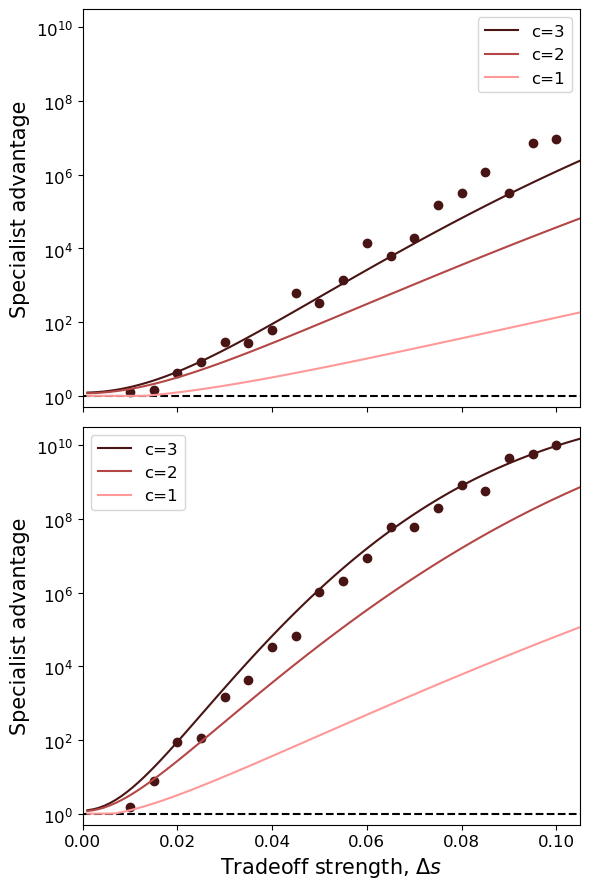

In [17]:
tau = period/2

xc = sg*2*np.log(N*sg)/np.log(sg/ug)
v = (2*sg**2 *np.log(N*sg))/(np.log(sg/ug)**2)

colors = [(255/255, 152/255, 152/255), (180/255, 70/255, 70/255), (72/255, 20/255, 20/255)]

s_tradeoff_range = np.linspace(0.001, 0.12, 100)

fig, axes = plt.subplots(len(period_CV_vals)-1, 1, sharex=True, figsize=(6, 9))

pfix_gen = pfix_gen_rare(sg, xc, v)

for j in range(1,len(period_CV_vals)):

    ax = axes[j-1]
    ax.axhline(y=1, color='black', linestyle='--')

    ax.scatter(s_tradeoff_vals, pfix_ratios[:, j], marker="o", color=colors[2])

    pfix_spec1 = pfix_spec_rare_stochastic(sg, s_tradeoff_range, tau, xc, v, period_CV_vals[j] * period / np.sqrt(2), c=1, calc_type=1)
    pfix_spec2 = pfix_spec_rare_stochastic(sg, s_tradeoff_range, tau, xc, v, period_CV_vals[j] * period / np.sqrt(2), c=2, calc_type=1)
    pfix_spec3 = pfix_spec_rare_stochastic(sg, s_tradeoff_range, tau, xc, v, period_CV_vals[j] * period / np.sqrt(2), c=3, calc_type=1)

    ax.plot(s_tradeoff_range, np.maximum(1, pfix_spec3/pfix_gen), color=colors[2], linewidth=1.5, label='c=3')
    ax.plot(s_tradeoff_range, np.maximum(1, pfix_spec2/pfix_gen), color=colors[1], linewidth=1.5, label='c=2')
    ax.plot(s_tradeoff_range, np.maximum(1, pfix_spec1/pfix_gen), color=colors[0], linewidth=1.5, label='c=1')

    ax.set_ylabel('Specialist advantage', fontsize=15)
    ax.legend(fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_yscale('log')
    ax.set_yticks([1, 1e2, 1e4, 1e6, 1e8, 1e10])
    ax.set_ylim([0.5, 10**10.5])

axes[-1].set_xlabel('Tradeoff strength, $\Delta s$', fontsize=15)
axes[-1].set_xlim([0, 0.105])

fig.tight_layout()

#plt.savefig(r'Figures\SI_Rare_Stochastic_Sampling_Long.pdf', format='pdf')

plt.show()

In [18]:
pfix_ratios = np.zeros((19,3))

sg = 0.02
ug = 3e-9
N = 1e20
period = 20
s_tradeoff_vals = [0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2]
period_CV_vals = [0, 0.4, 0.8]

for i in range(0,len(s_tradeoff_vals)):
    for j in range(0,len(period_CV_vals)):
        fname = 'Fig3_Data/N_' + str(N) + '_us_rare_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV_vals[j]) + '_small_output.pickle'

        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        pfix_gen = data['rate_gen']/(N*ug)
        pfix_spec = (np.array(data['fixations']) * np.array(data['pfix_adjustments'])).sum() / len(data['fixations'])

        pfix_ratios[i,j] = pfix_spec/pfix_gen

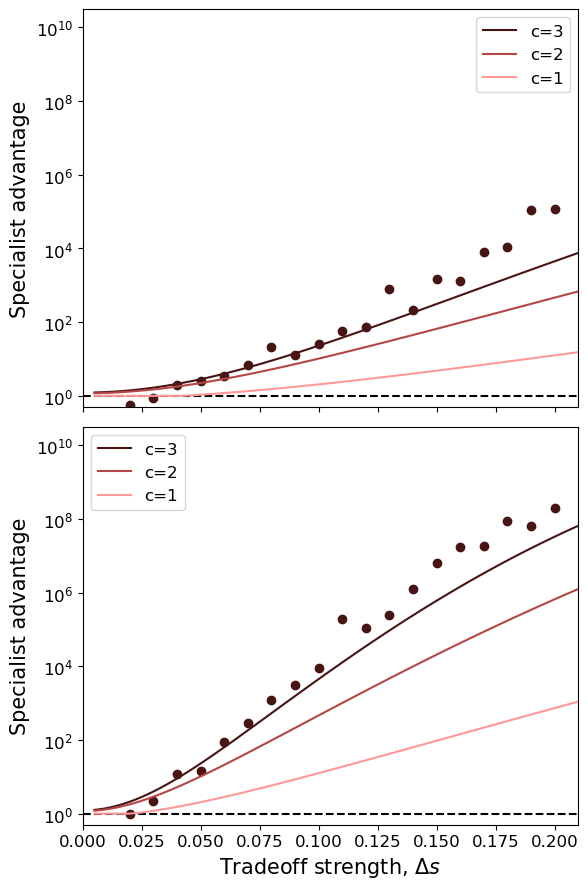

In [19]:
tau = period/2

xc = sg*2*np.log(N*sg)/np.log(sg/ug)
v = (2*sg**2 *np.log(N*sg))/(np.log(sg/ug)**2)

colors = [(255/255, 152/255, 152/255), (180/255, 70/255, 70/255), (72/255, 20/255, 20/255)]

s_tradeoff_range = np.linspace(0.005, 0.22, 100)

fig, axes = plt.subplots(len(period_CV_vals)-1, 1, sharex=True, figsize=(6, 9))

pfix_gen = pfix_gen_rare(sg, xc, v)

for j in range(1,len(period_CV_vals)):

    ax = axes[j-1]
    ax.axhline(y=1, color='black', linestyle='--')

    ax.scatter(s_tradeoff_vals, pfix_ratios[:, j], marker="o", color=colors[2])

    pfix_spec1 = pfix_spec_rare_stochastic(sg, s_tradeoff_range, tau, xc, v, period_CV_vals[j] * period / np.sqrt(2), c=1, calc_type=1)
    pfix_spec2 = pfix_spec_rare_stochastic(sg, s_tradeoff_range, tau, xc, v, period_CV_vals[j] * period / np.sqrt(2), c=2, calc_type=1)
    pfix_spec3 = pfix_spec_rare_stochastic(sg, s_tradeoff_range, tau, xc, v, period_CV_vals[j] * period / np.sqrt(2), c=3, calc_type=1)

    ax.plot(s_tradeoff_range, np.maximum(1, pfix_spec3/pfix_gen), color=colors[2], linewidth=1.5, label='c=3')
    ax.plot(s_tradeoff_range, np.maximum(1, pfix_spec2/pfix_gen), color=colors[1], linewidth=1.5, label='c=2')
    ax.plot(s_tradeoff_range, np.maximum(1, pfix_spec1/pfix_gen), color=colors[0], linewidth=1.5, label='c=1')

    ax.set_ylabel('Specialist advantage', fontsize=15)
    ax.legend(fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_yscale('log')
    ax.set_yticks([1, 1e2, 1e4, 1e6, 1e8, 1e10])
    ax.set_ylim([0.5, 10**10.5])

axes[-1].set_xlabel('Tradeoff strength, $\Delta s$', fontsize=15)
axes[-1].set_xlim([0, 0.21])

fig.tight_layout()

#plt.savefig(r'Figures\SI_Rare_Stochastic_Sampling_Short.pdf', format='pdf')

plt.show()

In [ ]:
# FIGURE S2, rare specialists in highly variable environments



sg = 0.02
ug = 3e-9
N = 1e20
period = 300
period_CV = 0
s_tradeoff_vals = [0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08]
p_long_vals = [0.005, 0.05]
pfix_ratios = np.zeros((len(s_tradeoff_vals),len(p_long_vals)))

for i in range(0,len(s_tradeoff_vals)):
        for j in range(0,len(p_long_vals)):

            fname = 'FigS2_Data/N_' + str(N) + '_us_rare_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV) + '_small_output_longtau_' + str(p_long_vals[j]) + '_2000.pickle'

            if os.path.isfile(fname):
                with open(fname,'rb') as file:
                    data = pickle.load(file)
            else:
                print(fname)
                continue

            pfix_gen = data['rate_gen']/(N*ug)
                
            pfix_spec = (np.array(data['fixations']) * np.array(data['pfix_adjustments'])).sum() / len(data['fixations'])
    
            pfix_ratios[i,j] = pfix_spec/pfix_gen

C:\Users\johnd\AppData\Local\Temp\ipykernel_19688\2937351973.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('Dark2', 3)


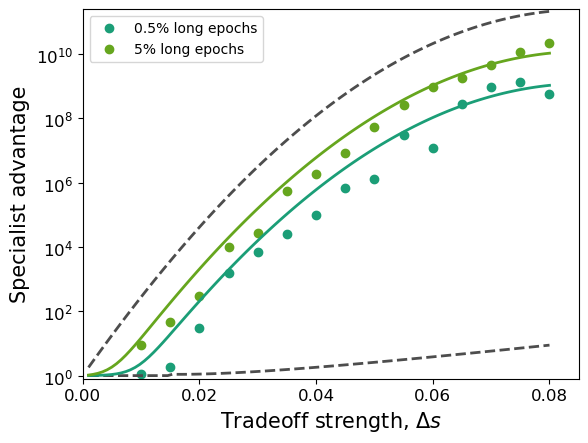

In [21]:
# FIGURE S2, rare specialists in highly variable environments

v = 2*sg**2*np.log(N*sg)/np.log(sg/ug)**2
xc = 2*sg*np.log(N*sg)/np.log(sg/ug)

s_tradeoff_range = np.linspace(0.001,0.08,100)
tau = period/2

pfix_lower = pfix_spec_rare_deterministic(sg, s_tradeoff_range, tau, xc, v) / pfix_gen_rare(sg, xc, v)
pfix_upper = np.zeros_like(s_tradeoff_range)
pfix_theory = np.zeros((len(s_tradeoff_range),len(p_long_vals)))

for i, s_tradeoff in enumerate(s_tradeoff_range):
    
    pfix_upper[i] = pfix_gen_rare(sg + s_tradeoff, xc, v) / pfix_gen_rare(sg, xc, v)
    pfix_theory[i,0] = pfix_lower[i]*(1-p_long_vals[0]) + pfix_upper[i]*p_long_vals[0]
    pfix_theory[i,1] = pfix_lower[i]*(1-p_long_vals[1]) + pfix_upper[i]*p_long_vals[1]

colors = cm.get_cmap('Dark2', 3)

plt.plot(s_tradeoff_vals, pfix_ratios[:,0], marker='o', color=colors(0), linestyle='None',label = '0.5% long epochs')
plt.plot(s_tradeoff_vals, pfix_ratios[:,1], marker='o', color=colors(1), linestyle='None',label = '5% long epochs')

plt.plot(s_tradeoff_range, pfix_lower,linewidth=2,color=[0.3,0.3,0.3],linestyle='--')
plt.plot(s_tradeoff_range, pfix_upper,linewidth=2,color=[0.3,0.3,0.3],linestyle='--')

plt.yscale('log')

plt.plot(s_tradeoff_range, pfix_theory[:,0],linewidth=2,color=colors(0))
plt.plot(s_tradeoff_range, pfix_theory[:,1],linewidth=2,color=colors(1))

plt.xlim([0.005, 0.085])
plt.xlabel('Tradeoff strength, $\Delta s$', fontsize=15)
plt.ylabel('Specialist advantage', fontsize=15)
plt.yticks([10**i for i in range(0, 11,2)], fontsize=12)
plt.xticks([0,0.02,0.04,0.06,0.08],fontsize=12)
plt.ylim([0.8,10**11.4])
plt.xlim([0,0.085])
plt.legend()

#plt.savefig(r'Figures\SI_Two_Tau.pdf', format='pdf')

plt.show()

In [ ]:
# FIGURE S3A, linear ansatz for specialization

s_tradeoff_vals1 = np.array([0.006, 0.007, 0.008, 0.009, 0.010, 0.011, 0.012, 0.013, 0.014])
s_tradeoff_vals2 = np.array([0.006, 0.007, 0.008, 0.009, 0.010, 0.011, 0.012, 0.013, 0.014])
period_vals1 = np.array([300, 400, 500])
period_vals2 = np.array([700, 800, 900])

# Panel A shows the bias curve at a single tradeoff strength over three periods
s_tradeoff_A = 0.01
period_vals_A = np.array([200, 400, 600])

vperp_est1 = np.zeros((len(s_tradeoff_vals1), len(period_vals1)))
vperp_est2 = np.zeros((len(s_tradeoff_vals2), len(period_vals2)))

bias_list = []
vperp_list = []

ug = 1e-6
N = 1e20
us = 1e-6
sg = 0.015

for period in period_vals_A:
    fname = 'FigS3_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_A) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_0_small_output.pickle'
    if os.path.isfile(fname):
        with open(fname,'rb') as file:
            data = pickle.load(file)
    else:
        print(fname)
        continue

    bias = np.array(data['bias_num'])/(np.array(data['bias_den']))
    bias_list.append(bias)
    vperp_list.append(s_tradeoff_A*np.polyfit(range(len(bias) // 2), bias[:len(bias) // 2], 1)[0])

for i in range(len(s_tradeoff_vals1)):
    for j in range(len(period_vals1)):
        fname = 'FigS3_Data//N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals1[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period_vals1[j]) + '_dtau_0_small_output.pickle'
        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        bias = np.array(data['bias_num'])/(np.array(data['bias_den']))
        vperp_est1[i,j] = s_tradeoff_vals1[i]*np.polyfit(range(len(bias) // 2), bias[:len(bias) // 2], 1)[0]

ug = 1e-15
N = 1e100
us = 1e-15
sg = 0.015

for i in range(len(s_tradeoff_vals2)):
    for j in range(len(period_vals2)):
        fname = 'FigS3_Data//N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals2[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period_vals2[j]) + '_dtau_0_small_output.pickle'
        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        bias = np.array(data['bias_num'])/(np.array(data['bias_den']))
        vperp_est2[i,j] = s_tradeoff_vals2[i]*np.polyfit(range(len(bias) // 2), bias[:len(bias) // 2], 1)[0]

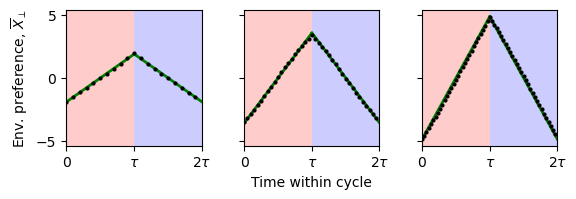

In [25]:
point_spacing = 10

fig, axs = plt.subplots(1, 3, sharey=True, figsize=(6, 2))

for i in range(3):
    xvals = np.linspace(0,1,len(bias_list[i])+1)[:-1]
    yvals = bias_list[i]-np.mean(bias_list[i])
    xmid = xvals[len(xvals)//2]

    ax = axs[i]
    ax.axvspan(0, xmid, color='red', alpha=0.2, linewidth=0)
    ax.axvspan(xmid, xvals[-1], color='blue', alpha=0.2, linewidth=0)

    ax.plot(xvals[:len(xvals)//2], (period_vals_A[i]*xvals[:len(xvals)//2]*vperp_list[i] - vperp_list[i]*period_vals_A[i]/4)/0.01,color=[0,0.5,0],linewidth=2)
    ax.plot(xvals[len(xvals)//2:], (-period_vals_A[i]*xvals[len(xvals)//2:]*vperp_list[i] + 3*vperp_list[i]*period_vals_A[i]/4)/0.01,color=[0,0.5,0],linewidth=2)

    ax.plot(xvals[::point_spacing], yvals[::point_spacing], color='black', linestyle='none', marker='o', markersize=2)
    ax.set_yticks([-5,0,5])

    ax.set_xticks([0, xmid, xvals[-1]])
    ax.set_xlim([0,xvals[-1]])
    ax.set_xticklabels(['0', r'$\tau$', r'$2\tau$'])
    ax.set_box_aspect(1)

    if i == 1: ax.set_xlabel('Time within cycle')
    if i == 0: ax.set_ylabel('Env. preference, $\overline{X}_\perp$')

plt.tight_layout()
#plt.savefig(r'Figures\SI_Environmental_Bias.pdf', format='pdf')

plt.show()

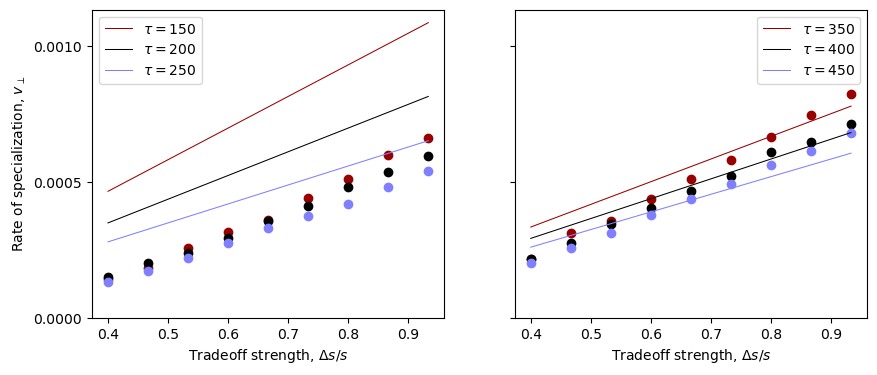

In [26]:
# FIGURE S3B, rate of specialization in periodic environments

ug1 = 1e-6
sg1 = 0.015
N1 = 1e20

ug2 = 1e-15
sg2 = 0.015
N2 = 1e100

vpar1 = 2*sg1**2*np.log(N1*sg1)/np.log(sg1/ug1)**2
vpar2 = 2*sg2**2*np.log(N2*sg2)/np.log(sg2/ug2)**2

xc1 = vpar1 / sg1 * np.log(sg1/ug1) + sg1/2
xc2 = vpar2 / sg2 * np.log(sg2/ug2) + sg2/2

vperp_pred1 = (1-1/np.exp(1))*2*s_tradeoff_vals1[:,None]*xc1/(sg1*(period_vals1/2))
vperp_pred2 = (1-1/np.exp(1))*2*s_tradeoff_vals2[:,None]*xc2/(sg2*(period_vals2/2))

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

period_colors = [[0.6,0,0], 'black', [0.5,0.5,1]]

for j, col in enumerate(period_colors):
    axs[0].plot(s_tradeoff_vals1/sg1, vperp_est1[:,j], marker='o', color=col, linestyle='None')

for j, col in enumerate(period_colors):
    axs[0].plot(s_tradeoff_vals1/sg1, vperp_pred1[:,j], color=col, linewidth=0.75, label=r'$\tau = $' + str(period_vals1[j]//2))
    
axs[0].set_ylim(bottom = 0)
axs[0].set_yticks([0,0.0005,0.001])
axs[0].set_ylabel('Rate of specialization, $v_\perp$')
axs[0].set_xlabel('Tradeoff strength, $\Delta s/s$')
axs[0].legend()

for j, col in enumerate(period_colors):
    axs[1].plot(s_tradeoff_vals2/sg2, vperp_est2[:,j], marker='o', color=col, linestyle='None')

for j, col in enumerate(period_colors):
    axs[1].plot(s_tradeoff_vals2/sg2, vperp_pred2[:,j], color=col, linewidth=0.75, label=r'$\tau = $' + str(period_vals2[j]//2))

axs[1].legend()

axs[1].set_xlabel('Tradeoff strength, $\Delta s/s$')

#plt.savefig(r'Figures\SI_Specialization_Rate.pdf', format='pdf')
plt.show()

In [27]:
# FIGURE S4A, details of optimal mutational path

sg = 0.02
ug = 3e-9
N = 1e20
period = 400
s_tradeoff = 0.05
us = 3e-9

fname = 'Highly_Sampled_Data/Combined_Data_N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_0.pickle'

with open(fname, 'rb') as file:
    data = pickle.load(file)

all_fixations = data['all_fixations']
all_adjustments = data['all_adjustments']
all_fix_starts = data['all_fix_starts']
all_bgs = data['all_bgs']
all_muttypes = data['all_muttypes']
bias = data['bias']
bias_std = data['bias_std']
vpar_est = data['v_est']

In [28]:
mod_starts = np.mod(all_fix_starts,period)
bg_bias = np.array([bg[1]- bg[2] for bg in all_bgs])

successful = all_fixations == 1
time_bins = np.linspace(0,period,50)
n_bins = len(time_bins) - 1
 
avg_mut = np.zeros(n_bins)
avg_base = np.zeros(n_bins)
avg_time = np.zeros(n_bins)
 
for i in range(n_bins):
    mask = np.logical_and(successful, np.logical_and(mod_starts >= time_bins[i], mod_starts < time_bins[i+1]))
    w = all_adjustments[mask]
    w[all_muttypes[mask] == 0] *= 2 # Correct for weighting of generalist mutations
    wsum = np.sum(w)
 
    bg_base = bg_bias[mask] + bias[mod_starts[mask].astype(int)]
    bg_plus_mut = all_muttypes[mask] + bg_base
 
    avg_mut[i] = np.sum(bg_plus_mut*w)/wsum
    avg_base[i] = np.sum(bg_base*w)/wsum
    avg_time[i] = np.sum(np.mod(all_fix_starts[mask], period)*w)/wsum

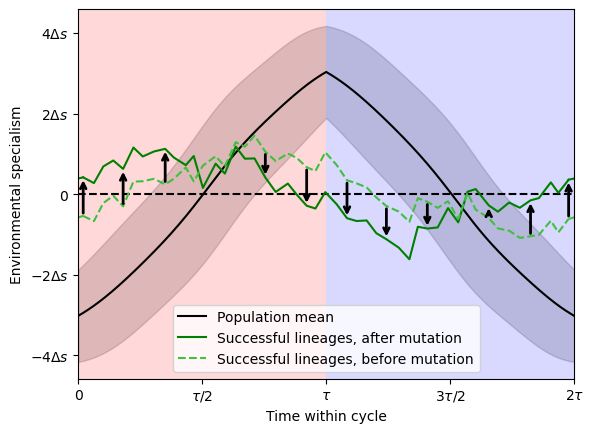

In [29]:
tau = period/2

plt.plot([0,period],[0,0],color='black',linestyle='--')
plt.plot(s_tradeoff*(bias-np.mean(bias)),label='Population mean',color='black')
plt.fill_between(np.arange(len(bias)), s_tradeoff*(bias - bias_std - np.mean(bias)), s_tradeoff*(bias + bias_std - np.mean(bias)), color='black', alpha=0.15)

plt.plot(avg_time, s_tradeoff*(avg_mut-np.mean(bias)), label='Successful lineages, after mutation',color='green',marker='None')
plt.plot(avg_time, s_tradeoff*(avg_base-np.mean(bias)), label='Successful lineages, before mutation',color=[0.25,0.75,0.25],marker='None',linestyle='--')

arrow_list = [0,4,8,18,22,26,30,34,40,44,48]
for x, y_start, y_end in zip(avg_time[arrow_list], avg_base[arrow_list], avg_mut[arrow_list]):
    y0 = s_tradeoff * (y_start - np.mean(bias))
    y1 = s_tradeoff * (y_end - np.mean(bias))
    plt.annotate(
        "", 
        xytext=(x, y0), 
        xy=(x, y1), 
        arrowprops=dict(arrowstyle="->", linewidth=2, color='black')
    )

end_slope = (s_tradeoff*(avg_mut-np.mean(bias))[0] - s_tradeoff*(avg_mut-np.mean(bias))[-1])/(period-avg_time[-1]+avg_time[0])
plt.plot([avg_time[-1], period], [s_tradeoff*(avg_mut-np.mean(bias))[-1], s_tradeoff*(avg_mut-np.mean(bias))[-1] + end_slope*(period-avg_time[-1])], color='green')
plt.plot([0,avg_time[0]], [s_tradeoff*(avg_mut-np.mean(bias))[0] - end_slope*avg_time[0], s_tradeoff*(avg_mut-np.mean(bias))[0]], color='green')

end_slope = (s_tradeoff*(avg_base-np.mean(bias))[0] - s_tradeoff*(avg_base-np.mean(bias))[-1])/(period-avg_time[-1]+avg_time[0])
plt.plot([avg_time[-1], period], [s_tradeoff*(avg_base-np.mean(bias))[-1], s_tradeoff*(avg_base-np.mean(bias))[-1] + end_slope*(period-avg_time[-1])],color=[0.25,0.75,0.25],marker='None',linestyle='--')
plt.plot([0,avg_time[0]], [s_tradeoff*(avg_base-np.mean(bias))[0] - end_slope*avg_time[0], s_tradeoff*(avg_base-np.mean(bias))[0]],color=[0.25,0.75,0.25],marker='None',linestyle='--')

plt.xticks([0, tau/2, tau, 3*tau/2, 2*tau], ['0', r'$\tau/2$', r'$\tau$', r'$3\tau/2$', r'$2\tau$'])
plt.xlim([0,period])

plt.yticks([-4*s_tradeoff, -2*s_tradeoff, 0, 2*s_tradeoff, 4*s_tradeoff], [r'$-4\Delta s$', r'$-2\Delta s$', r'$0$', r'$2\Delta s$', r'$4\Delta s$'])

plt.xlabel('Time within cycle')
plt.ylabel('Environmental specialism')
plt.legend()

plt.axvspan(0,period/2, facecolor='red', alpha=0.15)
plt.axvspan(period/2,period, facecolor='blue', alpha=0.15)
#plt.savefig(r'Figures\SI_Freq_Spec_Background_Landing.pdf', format='pdf')

plt.show()

In [ ]:
# FIGURE S4B, optimal mutational path in asymptotically large populations

sg = 0.03
ug = 5e-9
N = 1e40
period = 400
s_tradeoff = 0.05
us = 5e-9

fname = 'Highly_Sampled_Data/Combined_Data_N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_0.pickle'

with open(fname, 'rb') as file:
    data = pickle.load(file)

all_fixations2 = data['all_fixations']
all_adjustments2 = data['all_adjustments']
all_fix_starts2 = data['all_fix_starts']
all_bgs2 = data['all_bgs']
all_muttypes2 = data['all_muttypes']
bias2 = data['bias']
bias_std2 = data['bias_std']

In [31]:
time_bins = np.linspace(0,period,30)
avg_mut = np.zeros(len(time_bins)-1)
avg_base = np.zeros(len(time_bins)-1)
avg_time = np.zeros(len(time_bins)-1)

bg_bias = np.array([bg[1]- bg[2] for bg in all_bgs2])

mod_starts = np.mod(all_fix_starts2, period)
successful = all_fixations2 == 1

for i in range(0,len(time_bins)-1):
    mask = np.logical_and(successful, np.logical_and(mod_starts >= time_bins[i], mod_starts < time_bins[i+1]))
    w = all_adjustments2[mask]
    w[all_muttypes2[mask] == 0] *= 2 # Correct for weighting of generalist mutations
    wsum = np.sum(w)

    bg_base = bg_bias[mask] + bias2[mod_starts[mask].astype(int)]
    bg_plus_mut = all_muttypes2[mask] + bg_base

    avg_mut[i] = np.sum(bg_plus_mut*w)/wsum
    avg_base[i] = np.sum(bg_base*w)/wsum
    avg_time[i] = np.sum(mod_starts[mask]*w)/wsum

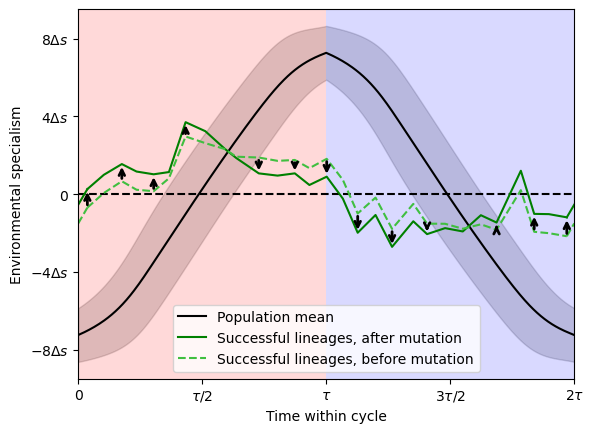

In [32]:
tau = period/2

plt.plot([0,period],[0,0],color='black',linestyle='--')
plt.plot(s_tradeoff*(bias2-np.mean(bias2)),label='Population mean',color='black')
plt.fill_between(np.arange(len(bias2)), s_tradeoff*(bias2 - bias_std2 - np.mean(bias2)), s_tradeoff*(bias2 + bias_std2 - np.mean(bias2)), color='black', alpha=0.15)

plt.plot(avg_time, s_tradeoff*(avg_mut-np.mean(bias2)), label='Successful lineages, after mutation',color='green',marker='None')
plt.plot(avg_time, s_tradeoff*(avg_base-np.mean(bias2)), label='Successful lineages, before mutation',color=[0.25,0.75,0.25],marker='None',linestyle='--')

arrow_list = [0,2,4,6,10,12,14,16,18,20,24,26,28]
for x, y_start, y_end in zip(avg_time[arrow_list], avg_base[arrow_list], avg_mut[arrow_list]):
    y0 = s_tradeoff * (y_start - np.mean(bias2))
    y1 = s_tradeoff * (y_end - np.mean(bias2))
    plt.annotate(
        "", 
        xytext=(x, y0), 
        xy=(x, y1), 
        arrowprops=dict(arrowstyle="->", linewidth=2, color='black')
    )

end_slope = (s_tradeoff*(avg_mut-np.mean(bias2))[0] - s_tradeoff*(avg_mut-np.mean(bias2))[-1])/(period-avg_time[-1]+avg_time[0])
plt.plot([avg_time[-1], period], [s_tradeoff*(avg_mut-np.mean(bias2))[-1], s_tradeoff*(avg_mut-np.mean(bias2))[-1] + end_slope*(period-avg_time[-1])], color='green')
plt.plot([0,avg_time[0]], [s_tradeoff*(avg_mut-np.mean(bias2))[0] - end_slope*avg_time[0], s_tradeoff*(avg_mut-np.mean(bias2))[0]], color='green')

end_slope = (s_tradeoff*(avg_base-np.mean(bias2))[0] - s_tradeoff*(avg_base-np.mean(bias2))[-1])/(period-avg_time[-1]+avg_time[0])
plt.plot([avg_time[-1], period], [s_tradeoff*(avg_base-np.mean(bias2))[-1], s_tradeoff*(avg_base-np.mean(bias2))[-1] + end_slope*(period-avg_time[-1])],color=[0.25,0.75,0.25],marker='None',linestyle='--')
plt.plot([0,avg_time[0]], [s_tradeoff*(avg_base-np.mean(bias2))[0] - end_slope*avg_time[0], s_tradeoff*(avg_base-np.mean(bias2))[0]],color=[0.25,0.75,0.25],marker='None',linestyle='--')

plt.xticks([0, tau/2, tau, 3*tau/2, 2*tau], ['0', r'$\tau/2$', r'$\tau$', r'$3\tau/2$', r'$2\tau$'])
plt.xlim([0,period])

plt.yticks([-8*s_tradeoff, -4*s_tradeoff, 0, 4*s_tradeoff, 8*s_tradeoff], [r'$-8\Delta s$', r'$-4\Delta s$', r'$0$', r'$4\Delta s$', r'$8\Delta s$'])

plt.xlabel('Time within cycle')
plt.ylabel('Environmental specialism')
plt.legend()

plt.axvspan(0,period/2, facecolor='red', alpha=0.15)
plt.axvspan(period/2,period, facecolor='blue', alpha=0.15)
#plt.savefig(r'Figures\SI_Large_N_Optimal_Path.pdf', format='pdf')

plt.show()

In [33]:
# FIGURE S5, two-dimensional fitness distribution

sg = 0.02
ug = 3e-9
N = 1e20
period = 400
s_tradeoff = 0.05
us = 3e-9

fitness_dist = np.zeros((period,40,40))

for i in range(0,100):
    fname = 'FigS5_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_0_with_extra_info_' + str(i) + '.pickle'
    if os.path.isfile(fname):
        with open(fname,'rb') as file:
            data = pickle.load(file)
    else:
        print(fname)
        continue

    fitness_dist += np.array(data['fitness_dist'])/np.array(data['bias_den'].reshape((period,1,1))) / 100


In [36]:
sg = 0.02
ug = 3e-9
N = 1e20
period = 400
s_tradeoff = 0.05
us = 3e-9

fname = 'Highly_Sampled_Data/Combined_Data_N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_0.pickle'

with open(fname, 'rb') as file:
    data = pickle.load(file)

all_fixations = data['all_fixations']
all_adjustments = data['all_adjustments']
all_fix_starts = data['all_fix_starts']
all_bgs = data['all_bgs']
all_muttypes = data['all_muttypes']
bias = data['bias']
bias_std = data['bias_std']
vpar_est = data['v_est']

xc_est = vpar_est/sg * np.log(sg/ug) + sg/2
vperp_est = s_tradeoff*np.polyfit(range(len(bias) // 2), bias[:len(bias) // 2], 1)[0]

In [37]:
time_bins = np.linspace(0,period,30)
avg_mut_bias = np.zeros(len(time_bins)-1)
avg_mut_tot = np.zeros(len(time_bins)-1)
std_mut_bias = np.zeros(len(time_bins)-1)
std_mut_tot = np.zeros(len(time_bins)-1)
avg_time = np.zeros(len(time_bins)-1)

bg_bias = np.array([bg[1]- bg[2] for bg in all_bgs])
bg_tot = np.array([bg[0] + bg[1] + bg[2] for bg in all_bgs])

mod_starts = np.mod(all_fix_starts, period)

for i in range(0,len(time_bins)-1):
    mask = np.logical_and(mod_starts >= time_bins[i], mod_starts < time_bins[i+1])
    mask = np.logical_and(mask, all_fixations == 1)

    bg_plus_mut_bias = all_muttypes[mask] + bg_bias[mask] + bias[np.mod(all_fix_starts[mask],period).astype(int)]
    bg_plus_mut_tot = 1 + bg_tot[mask]

    w = all_adjustments[mask]
    w[all_muttypes[mask] == 0] *= 2 # Correct for weighting of generalist mutations
    p = w / np.sum(w)

    avg_mut_bias[i] = np.sum(bg_plus_mut_bias*p)
    avg_mut_tot[i] = np.sum(bg_plus_mut_tot*p)

    std_mut_bias[i] = np.sqrt((p * (bg_plus_mut_bias - avg_mut_bias[i])**2).sum())
    std_mut_tot[i] = np.sqrt((p * (bg_plus_mut_tot - avg_mut_tot[i])**2).sum())

    avg_time[i] = np.sum(np.mod(all_fix_starts[mask],period)*p)

In [38]:
x_target = np.arange(0, period + 1)

avg_time_ext = np.concatenate(([avg_time[-1] - period], avg_time, [avg_time[0] + period]))
avg_mut_bias_ext = np.concatenate(([avg_mut_bias[-1]], avg_mut_bias, [avg_mut_bias[0]]))
avg_mut_tot_ext = np.concatenate(([avg_mut_tot[-1]], avg_mut_tot, [avg_mut_tot[0]]))
std_mut_bias_ext = np.concatenate(([std_mut_bias[-1]], std_mut_bias, [std_mut_bias[0]]))
std_mut_tot_ext = np.concatenate(([std_mut_tot[-1]], std_mut_tot, [std_mut_tot[0]]))

# Interpolators
interp_bias = interp1d(avg_time_ext, avg_mut_bias_ext, kind='linear', assume_sorted=True)
interp_tot = interp1d(avg_time_ext, avg_mut_tot_ext, kind='linear', assume_sorted=True)
interp_std_bias = interp1d(avg_time_ext, std_mut_bias_ext, kind='linear', assume_sorted=True)
interp_std_tot = interp1d(avg_time_ext, std_mut_tot_ext, kind='linear', assume_sorted=True)

# Evaluate at desired points (mod T for periodicity)
avg_mut_bias_interp = interp_bias(np.mod(x_target - avg_time[0], period) + avg_time[0])
avg_mut_tot_interp = interp_tot(np.mod(x_target - avg_time[0], period) + avg_time[0])
std_mut_bias_interp = interp_std_bias(np.mod(x_target - avg_time[0], period) + avg_time[0])
std_mut_tot_interp = interp_std_tot(np.mod(x_target - avg_time[0], period) + avg_time[0])

In [ ]:
import imageio
import os

def draw_time_slider(ax, phase):
    """Blue/red stripes, half a period each, sliding left under a fixed centre line."""
    for k in range(int(np.floor(2*(phase - 0.5))), int(np.ceil(2*(phase + 0.5)))):
        left = max(0.5*k, phase - 0.5) - phase
        right = min(0.5*(k + 1), phase + 0.5) - phase
        ax.add_patch(patches.Rectangle((left, 0), right - left, 1, facecolor='red' if k % 2 == 0 else 'blue', alpha=0.3, edgecolor='none'))
    ax.axvline(0, color='black', linewidth=3)
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])

frame_dir = "Figures/Frames"
os.makedirs(frame_dir, exist_ok=True)

filenames = []
for i in range(fitness_dist.shape[0]):
    ny, nx = fitness_dist.shape[1:]
    x_grid = np.arange(nx)
    y_grid = np.arange(ny)

    density = fitness_dist[i, :, :]
    density_sum = np.sum(density)

    mean_x = np.sum(density * x_grid[np.newaxis, :]) / density_sum
    mean_y = np.sum(density * y_grid[:, np.newaxis]) / density_sum

    x_shifted = (x_grid - mean_x)/2
    y_shifted = (y_grid - mean_y)/2 + bias[i] - np.mean(bias)
    extent = [x_shifted[0], x_shifted[-1], y_shifted[0], y_shifted[-1]]

    log_density = np.log10(fitness_dist[i, :, :].T)

    plt.imshow(log_density,
            aspect='auto', origin='lower', cmap='viridis',
            extent=extent, vmin=-29,vmax=0)

    cbar = plt.colorbar(label='Density')
    cbar.set_ticks([0, -5, -10, -15, -20, -25])
    cbar.set_ticklabels([r'$10^0$', r'$10^{-5}$', r'$10^{-10}$', r'$10^{-15}$', r'$10^{-20}$', r'$10^{-25}$'])
    plt.xlabel('Relative average fitness')
    plt.ylabel('Environmental specialism')
    plt.yticks([-9, -6, -3, 0, 3, 6, 9], [r'$-9\Delta s$', r'$-6\Delta s$', r'$-3\Delta s$', r'$0$', r'$3\Delta s$', r'$6\Delta s$', r'$9\Delta s$'])
    plt.xticks([-9, -6, -3, 0, 3, 6, 9], [r'$-9s$', r'$-6s$', r'$-3s$', r'$0$', r'$3s$', r'$6s$', r'$9s$'])
    plt.xlim([-10,10])
    plt.ylim([-11,11])

    levels = [-7,-4,-1]

    X, Y = np.meshgrid((x_grid - mean_x)/2, (y_grid - mean_y)/2 + bias[i] - np.mean(bias), indexing='ij')

    plt.contour(X.T, Y.T, log_density, levels=levels,
                colors='magenta', linewidths=3)
    
    y_vals = s_tradeoff * np.linspace(-15, 15, 1000)
    t_factor = period/4 - np.min((i, period-i))
    x_vals = xc_est - s_tradeoff*vpar_est*period/(8*sg) - (vpar_est*y_vals/xc_est) * t_factor + vpar_est*vperp_est*t_factor**2/(2*xc_est) + vpar_est*vperp_est*period**2/(4*24*xc_est)

    mask = np.abs(y_vals/s_tradeoff + bias[i] - np.mean(bias)) < 9

    plt.plot(x_vals[mask]/sg, y_vals[mask]/s_tradeoff + bias[i] - np.mean(bias),color='black', linewidth=3)

    x_center = avg_mut_tot_interp[i]
    y_center = avg_mut_bias_interp[i] - np.mean(bias)
    width = 2*std_mut_tot_interp[i]    # x-length of ellipse
    height = 2*std_mut_bias_interp[i]  # y-length of ellipse

    ellipse = patches.Ellipse(
        (x_center, y_center),
        width=width,
        height=height,
        facecolor='pink',
        edgecolor='black',
        linewidth=2
    )

    ax = plt.gca()  # get current axes
    ax.add_patch(ellipse)

    fig = plt.gcf()
    pos = ax.get_position()
    slider_ax = fig.add_axes([pos.x0, pos.y1 + 0.02, pos.width, 0.05])
    draw_time_slider(slider_ax, i/fitness_dist.shape[0])
    
    # Save the figure
    filename = os.path.join(frame_dir, f'frame_{i:03d}.png')
    plt.savefig(filename)
    plt.close()
    filenames.append(filename)

# Create a GIF
with imageio.get_writer('Figures/Fitness_Distribution_Cycle.gif', mode='I', duration=0.01, loop=0) as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)

C:\Users\johnd\AppData\Local\Temp\ipykernel_23540\1498920238.py:39: RuntimeWarning: divide by zero encountered in log10
  log_density = np.log10(fitness_dist[i, :, :].T)
C:\Users\johnd\AppData\Local\Temp\ipykernel_23540\1498920238.py:39: RuntimeWarning: divide by zero encountered in log10
  log_density = np.log10(fitness_dist[i, :, :].T)
C:\Users\johnd\AppData\Local\Temp\ipykernel_23540\1498920238.py:39: RuntimeWarning: divide by zero encountered in log10
  log_density = np.log10(fitness_dist[i, :, :].T)
C:\Users\johnd\AppData\Local\Temp\ipykernel_23540\1498920238.py:39: RuntimeWarning: divide by zero encountered in log10
  log_density = np.log10(fitness_dist[i, :, :].T)
C:\Users\johnd\AppData\Local\Temp\ipykernel_23540\1498920238.py:39: RuntimeWarning: divide by zero encountered in log10
  log_density = np.log10(fitness_dist[i, :, :].T)
C:\Users\johnd\AppData\Local\Temp\ipykernel_23540\1498920238.py:39: RuntimeWarning: divide by zero encountered in log10
  log_density = np.log10(fitne

C:\Users\johnd\AppData\Local\Temp\ipykernel_19688\1336886617.py:21: RuntimeWarning: divide by zero encountered in log10
  log_density = np.log10(fitness_dist[i, :, :].T)
C:\Users\johnd\AppData\Local\Temp\ipykernel_19688\1336886617.py:21: RuntimeWarning: divide by zero encountered in log10
  log_density = np.log10(fitness_dist[i, :, :].T)
C:\Users\johnd\AppData\Local\Temp\ipykernel_19688\1336886617.py:21: RuntimeWarning: divide by zero encountered in log10
  log_density = np.log10(fitness_dist[i, :, :].T)
C:\Users\johnd\AppData\Local\Temp\ipykernel_19688\1336886617.py:21: RuntimeWarning: divide by zero encountered in log10
  log_density = np.log10(fitness_dist[i, :, :].T)
C:\Users\johnd\AppData\Local\Temp\ipykernel_19688\1336886617.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


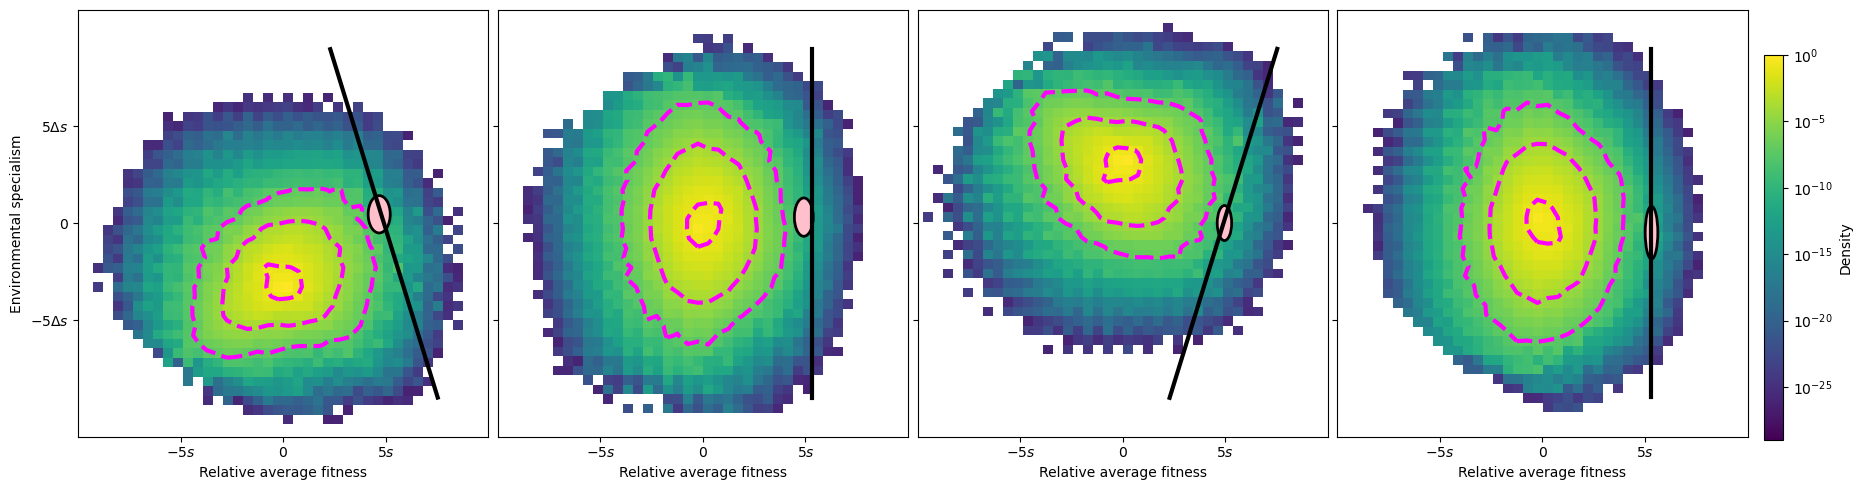

In [39]:
indices = [0, 100, 200, 300]
ny, nx = fitness_dist.shape[1:]
x_grid = np.arange(nx)
y_grid = np.arange(ny)

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

im = None

for ax, i in zip(axes, indices):
    density = fitness_dist[i, :, :]
    density_sum = np.sum(density)

    mean_x = np.sum(density * x_grid[np.newaxis, :]) / density_sum
    mean_y = np.sum(density * y_grid[:, np.newaxis]) / density_sum

    x_shifted = (x_grid - mean_x) / 2
    y_shifted = (y_grid - mean_y) / 2 + bias[i] - np.mean(bias)
    extent = [x_shifted[0], x_shifted[-1], y_shifted[0], y_shifted[-1]]

    log_density = np.log10(fitness_dist[i, :, :].T)

    im = ax.imshow(
        log_density,
        aspect='auto',
        origin='lower',
        cmap='viridis',
        extent=extent,
        vmin=-29, vmax=0
    )

    # Contour overlay
    levels = [-7, -4, -1]
    X, Y = np.meshgrid(
        (x_grid - mean_x) / 2,
        (y_grid - mean_y) / 2 + bias[i] - np.mean(bias),
        indexing='ij'
    )
    ax.contour(X.T, Y.T, log_density, levels=levels,
               colors='magenta', linewidths=3)
    
    y_vals = s_tradeoff * np.linspace(-15, 15, 1000)
    t_factor = period/4 - np.min((i, period-i))
    x_vals = xc_est - s_tradeoff*vpar_est*period/(8*sg) - (vpar_est*y_vals/xc_est) * t_factor + vpar_est*vperp_est*t_factor**2/(2*xc_est) + vpar_est*vperp_est*period**2/(4*24*xc_est)

    mask = np.abs(y_vals / s_tradeoff + bias[i] - np.mean(bias)) < 9
    ax.plot(x_vals[mask] / sg, y_vals[mask] / s_tradeoff + bias[i] - np.mean(bias),
            color='black', linewidth=3)

    # Ellipse overlay
    x_center = avg_mut_tot_interp[i]
    y_center = avg_mut_bias_interp[i] - np.mean(bias)
    width = 2 * std_mut_tot_interp[i]
    height = 2 * std_mut_bias_interp[i]
    ellipse = patches.Ellipse(
        (x_center, y_center),
        width=width,
        height=height,
        facecolor='pink',
        edgecolor='black',
        linewidth=2
    )
    ax.add_patch(ellipse)

    # Axes formatting
    ax.set_xticks([-5, 0, 5])
    ax.set_xticklabels([r'$-5s$', r'$0$', r'$5s$'])
    ax.set_xlim([-10, 10])
    ax.set_ylim([-11, 11])
    if ax is axes[0]:
        ax.set_yticks([-5,0,5])
        ax.set_yticklabels([r'$-5\Delta s$', r'$0$', r'$5\Delta s$'])
        ax.set_ylabel('Environmental specialism')
    ax.set_xlabel('Relative average fitness')

# Single shared colorbar
cbar = fig.colorbar(im, ax=axes, location='right', fraction=0.02, pad=-0.17)
cbar.set_label('Density')
cbar.set_ticks([0, -5, -10, -15, -20, -25])
cbar.set_ticklabels([r'$10^0$', r'$10^{-5}$', r'$10^{-10}$', r'$10^{-15}$', r'$10^{-20}$', r'$10^{-25}$'])

plt.tight_layout()
#plt.savefig(r'Figures\SI_Fitness_Dist_2D.pdf', format='pdf')

plt.show()

In [40]:
# FIGURE S6A, time-dependent fixation probability with frequent specialists

sg = 0.02
ug = 3e-9
N = 1e20
period = 400
s_tradeoff = 0.05
us = 3e-9

fname = 'Highly_Sampled_Data/Combined_Data_N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_0.pickle'

with open(fname, 'rb') as file:
    data = pickle.load(file)

all_fixations = data['all_fixations']
all_adjustments = data['all_adjustments']
all_fix_starts = data['all_fix_starts']
all_bgs = data['all_bgs']
all_muttypes = data['all_muttypes']
bias = data['bias']
bias_std = data['bias_std']
vpar_est = data['v_est']
vperp_est = data['vt_est']

In [41]:
time_bins = np.linspace(0,period,24)
pfix_s1 = np.zeros(len(time_bins)-1)
pfix_s2 = np.zeros(len(time_bins)-1)
pfix_g = np.zeros(len(time_bins)-1)

avg_time_s1 = np.zeros(len(time_bins)-1)
avg_time_s2 = np.zeros(len(time_bins)-1)
avg_time_g = np.zeros(len(time_bins)-1)

time_bins_overall = np.linspace(0,period/4,24)
pfix_overall_high_st = np.zeros(len(time_bins_overall)-1)
avg_time_overall_high_st = np.zeros(len(time_bins_overall)-1)

for i in range(0,len(time_bins)-1):
    mask = np.logical_and(np.mod(all_fix_starts,period) >= time_bins[i], np.mod(all_fix_starts,period) < time_bins[i+1])
    mask_s1 = np.logical_and(mask, all_muttypes == 1)
    mask_s2 = np.logical_and(mask, all_muttypes == -1)
    mask_g = np.logical_and(mask, all_muttypes == 0)
    
    avg_time_s1[i] = np.sum(np.mod(all_fix_starts[mask_s1],period)*all_adjustments[mask_s1])/np.sum(all_adjustments[mask_s1])
    avg_time_s2[i] = np.sum(np.mod(all_fix_starts[mask_s2],period)*all_adjustments[mask_s2])/np.sum(all_adjustments[mask_s2])
    avg_time_g[i] = np.sum(np.mod(all_fix_starts[mask_g],period)*all_adjustments[mask_g])/np.sum(all_adjustments[mask_g])

    pfix_s1[i] = np.sum(all_fixations[mask_s1]*all_adjustments[mask_s1])/len(all_adjustments[mask_s1])
    pfix_s2[i] = np.sum(all_fixations[mask_s2]*all_adjustments[mask_s2])/len(all_adjustments[mask_s2])
    pfix_g[i] = np.sum(all_fixations[mask_g]*all_adjustments[mask_g])/len(all_adjustments[mask_g])

for i in range(0,len(time_bins_overall)-1):
    R = np.mod(all_fix_starts,period/2)
    R = np.minimum(R, period/2 - R)

    mask = np.logical_and(R >= time_bins_overall[i], R < time_bins_overall[i+1])

    w = all_adjustments[mask]
    w[all_muttypes[mask] == 0] *= 3/2
    w[all_muttypes[mask] != 0] *= 3/4
    wsum = np.sum(w)

    avg_time_overall_high_st[i] = np.sum(R[mask]*w)/wsum
    pfix_overall_high_st[i] = np.sum(all_fixations[mask]*w)/wsum

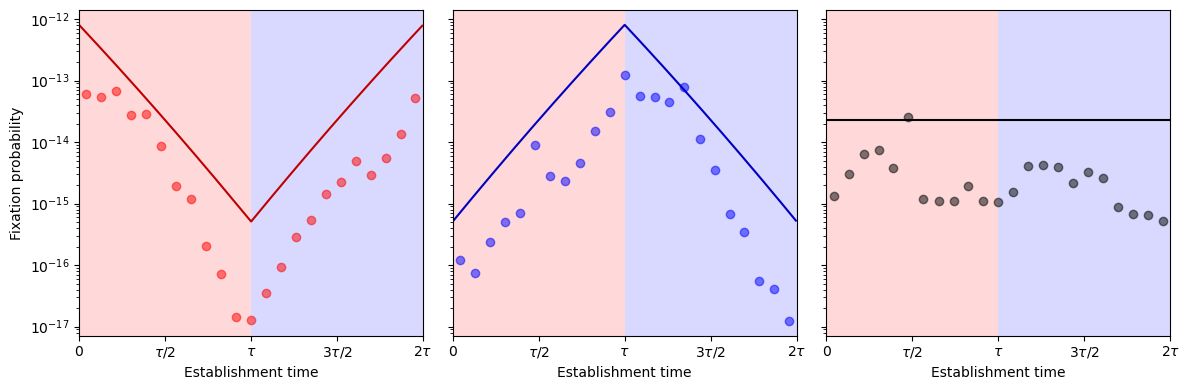

In [42]:
xc_est = vpar_est/sg * np.log(sg/ug) + sg/2

tau = period/2

x_vals = np.linspace(0,period-1,1000)

# Create subplots
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(12, 4))

# Specialist 1
params = dict(sg=sg, s_tradeoff=s_tradeoff, tau=tau, xc=xc_est, vpar=vpar_est, D=1)
axes[0].plot(avg_time_s1, pfix_s1, marker='o', color='red', linestyle='None', alpha=0.5)
axes[0].plot(x_vals,pfix_frequent_deterministic_time(t0=x_vals, **params), color=[0.75, 0, 0], label='Specialist 1')

axes[0].axvspan(0, period/2, facecolor='red', alpha=0.15)
axes[0].axvspan(period/2, period, facecolor='blue', alpha=0.15)
axes[0].set_xticks([0, tau/2, tau, 3*tau/2, 2*tau])
axes[0].set_xticklabels(['0', r'$\tau/2$', r'$\tau$', r'$3\tau/2$', r'$2\tau$'])
axes[0].set_xlim([0, period])
axes[0].set_yscale('log')
axes[0].set_xlabel('Establishment time')
axes[0].set_ylabel('Fixation probability')

# Specialist 2|
params = dict(sg=sg, s_tradeoff=s_tradeoff, tau=tau, xc=xc_est, vpar=vpar_est, D=-1)
axes[1].plot(avg_time_s2, pfix_s2, marker='o', color='blue', linestyle='None', alpha=0.5)
axes[1].plot(x_vals,pfix_frequent_deterministic_time(t0=x_vals, **params), color=[0, 0, 0.75], label='Specialist 2')

axes[1].axvspan(0, period/2, facecolor='red', alpha=0.15)
axes[1].axvspan(period/2, period, facecolor='blue', alpha=0.15)
axes[1].set_xticks([0, tau/2, tau, 3*tau/2, 2*tau])
axes[1].set_xticklabels(['0', r'$\tau/2$', r'$\tau$', r'$3\tau/2$', r'$2\tau$'])
axes[1].set_xlim([0, period])
axes[1].set_xlabel('Establishment time')
axes[1].set_yscale('log')

# Generalist
params = dict(sg=sg, s_tradeoff=s_tradeoff, tau=tau, xc=xc_est, vpar=vpar_est, D=0)
axes[2].plot(avg_time_g, pfix_g, marker='o', color='black', linestyle='None', alpha=0.5)
axes[2].plot(x_vals,pfix_frequent_deterministic_time(t0=x_vals, **params), color='black', label='Generalist')
axes[2].axvspan(0, period/2, facecolor='red', alpha=0.15)
axes[2].axvspan(period/2, period, facecolor='blue', alpha=0.15)
axes[2].set_xticks([0, tau/2, tau, 3*tau/2, 2*tau])
axes[2].set_xticklabels(['0', r'$\tau/2$', r'$\tau$', r'$3\tau/2$', r'$2\tau$'])
axes[2].set_xlim([0, period])
axes[2].set_xlabel('Establishment time')
axes[2].set_yscale('log')

plt.tight_layout()

#plt.savefig(r'Figures\SI_Frequent_Pfix_Time_Large_Tradeoff.pdf', format='pdf')
plt.show()



In [ ]:
N = 1e20
us = 1e-10
ug = 1e-10
sg = 0.022
s_tradeoff = 0.015
period = 600

fname = 'Highly_Sampled_Data/Combined_Data_N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_0.pickle'

with open(fname, 'rb') as file:
    data = pickle.load(file)

all_fixations = data['all_fixations']
all_adjustments = data['all_adjustments']
all_fix_starts = data['all_fix_starts']
all_bgs = data['all_bgs']
all_muttypes = data['all_muttypes']
bias = data['bias']
vpar_est = data['v_est']
vperp_est = data['vt_est']
xc_est = vpar_est/sg * np.log(sg/ug) + sg/2


In [44]:
time_bins = np.linspace(0,period,24)
pfix_s1 = np.zeros(len(time_bins)-1)
pfix_s2 = np.zeros(len(time_bins)-1)
pfix_g = np.zeros(len(time_bins)-1)

time_bins2 = np.linspace(0,period/4,24)
pfix_overall = np.zeros(len(time_bins2)-1)
avg_time_overall = np.zeros(len(time_bins2)-1)

avg_time_s1 = np.zeros(len(time_bins)-1)
avg_time_s2 = np.zeros(len(time_bins)-1)
avg_time_g = np.zeros(len(time_bins)-1)

for i in range(0,len(time_bins)-1):
    mask = np.logical_and(np.mod(all_fix_starts,period) >= time_bins[i], np.mod(all_fix_starts,period) < time_bins[i+1])
    mask_s1 = np.logical_and(mask, all_muttypes == -1)
    mask_s2 = np.logical_and(mask, all_muttypes == 1)
    mask_g = np.logical_and(mask, all_muttypes == 0)
    
    avg_time_s1[i] = np.sum(np.mod(all_fix_starts[mask_s1],period)*all_adjustments[mask_s1])/np.sum(all_adjustments[mask_s1])
    avg_time_s2[i] = np.sum(np.mod(all_fix_starts[mask_s2],period)*all_adjustments[mask_s2])/np.sum(all_adjustments[mask_s2])
    avg_time_g[i] = np.sum(np.mod(all_fix_starts[mask_g],period)*all_adjustments[mask_g])/np.sum(all_adjustments[mask_g])

    pfix_s1[i] = np.sum(all_fixations[mask_s1]*all_adjustments[mask_s1])/len(all_adjustments[mask_s1])
    pfix_s2[i] = np.sum(all_fixations[mask_s2]*all_adjustments[mask_s2])/len(all_adjustments[mask_s2])
    pfix_g[i] = np.sum(all_fixations[mask_g]*all_adjustments[mask_g])/len(all_adjustments[mask_g])

for i in range(0,len(time_bins2)-1):
    R = np.mod(all_fix_starts,period/2)
    R = np.minimum(R, period/2 - R)
    mask = np.logical_and(R >= time_bins2[i], R < time_bins2[i+1])

    w = all_adjustments[mask]
    w[all_muttypes[mask] == 0] *= 3/2
    w[all_muttypes[mask] != 0] *= 3/4
    wsum = np.sum(w)

    avg_time_overall[i] = np.sum(R[mask]*w)/wsum
    pfix_overall[i] = np.sum(all_fixations[mask]*w)/wsum


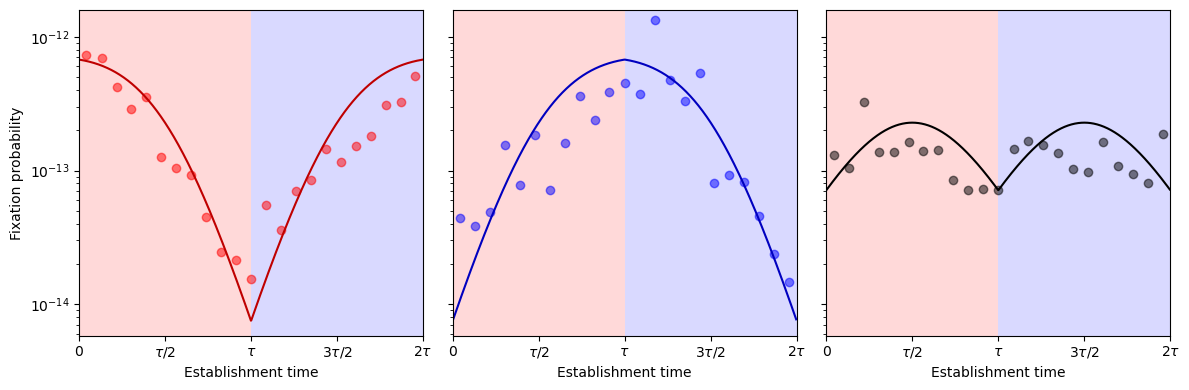

In [45]:
tau = period/2

x_vals = np.linspace(0,period-1,1000)

# Create subplots
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(12, 4))

# Specialist 1
axes[0].plot(avg_time_s1, pfix_s1, marker='o', color='red', linestyle='None', alpha=0.5)

axes[0].axvspan(0, period/2, facecolor='red', alpha=0.15)
axes[0].axvspan(period/2, period, facecolor='blue', alpha=0.15)
axes[0].set_xticks([0, tau/2, tau, 3*tau/2, 2*tau])
axes[0].set_xticklabels(['0', r'$\tau/2$', r'$\tau$', r'$3\tau/2$', r'$2\tau$'])
axes[0].set_xlim([0, period])
axes[0].set_yscale('log')
axes[0].set_xlabel('Establishment time')
axes[0].set_ylabel('Fixation probability')

params = dict(sg=sg, s_tradeoff=s_tradeoff, tau=tau, xc=xc_est, vpar=vpar_est, vperp=vperp_est, D=1)
axes[0].plot(x_vals,pfix_frequent_deterministic_small_time(t0=x_vals, **params), color=[0.75, 0, 0], label='Specialist 1')

# Specialist 2
axes[1].plot(avg_time_s2, pfix_s2, marker='o', color='blue', linestyle='None', alpha=0.5)

axes[1].axvspan(0, period/2, facecolor='red', alpha=0.15)
axes[1].axvspan(period/2, period, facecolor='blue', alpha=0.15)
axes[1].set_xticks([0, tau/2, tau, 3*tau/2, 2*tau])
axes[1].set_xticklabels(['0', r'$\tau/2$', r'$\tau$', r'$3\tau/2$', r'$2\tau$'])
axes[1].set_xlim([0, period])
axes[1].set_ylim(top = 10**-11.8)
axes[1].set_xlabel('Establishment time')
axes[1].set_yscale('log')
params = dict(sg=sg, s_tradeoff=s_tradeoff, tau=tau, xc=xc_est, vpar=vpar_est, vperp=vperp_est, D=-1)
axes[1].plot(x_vals,pfix_frequent_deterministic_small_time(t0=x_vals, **params), color=[0, 0, 0.75], label='Specialist 1')

# Generalist
axes[2].plot(avg_time_g, pfix_g, marker='o', color='black', linestyle='None', alpha=0.5)
axes[2].axvspan(0, period/2, facecolor='red', alpha=0.15)
axes[2].axvspan(period/2, period, facecolor='blue', alpha=0.15)
axes[2].set_xticks([0, tau/2, tau, 3*tau/2, 2*tau])
axes[2].set_xticklabels(['0', r'$\tau/2$', r'$\tau$', r'$3\tau/2$', r'$2\tau$'])
axes[2].set_xlim([0, period])
axes[2].set_xlabel('Establishment time')
axes[2].set_yscale('log')
params = dict(sg=sg, s_tradeoff=s_tradeoff, tau=tau, xc=xc_est, vpar=vpar_est, vperp=vperp_est, D=0)
axes[2].plot(x_vals,pfix_frequent_deterministic_small_time(t0=x_vals, **params), color=[0, 0, 0], label='Specialist 1')

plt.tight_layout()

#plt.savefig(r'Figures\SI_Frequent_Pfix_Time_Small_Tradeoff.pdf', format='pdf')
plt.show()



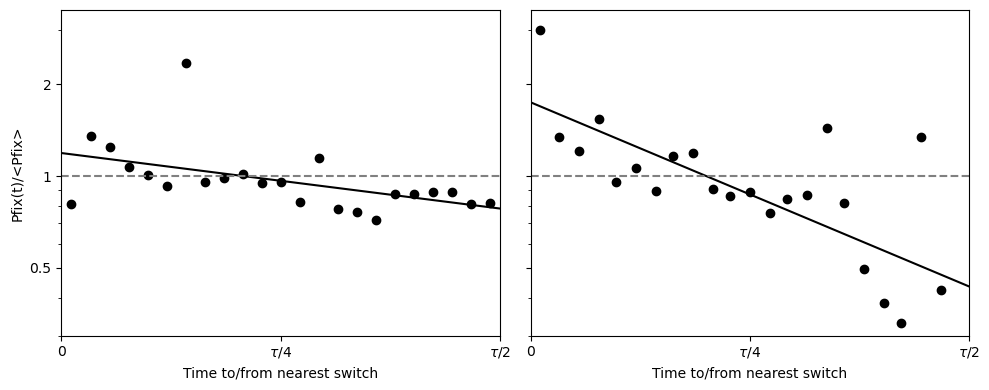

In [46]:
# FIGURE S6B, successful mutations become concentrated near environmental switches in bursting regime

period1 = 400
period2 = 600

x1 = avg_time_overall/(period2/4)
y1 = pfix_overall/np.mean(pfix_overall)

x2 = avg_time_overall_high_st/(period1/4)
y2 = pfix_overall_high_st/np.mean(pfix_overall_high_st)

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10,4))

# Left subplot
ax1.plot(x1, y1, color='black', marker='o', linestyle='None')
m1, b1 = np.polyfit(x1, np.log(y1), 1)

# Right subplot
ax2.plot(x2, y2, color='black', marker='o', linestyle='None')
m2, b2 = np.polyfit(x2, np.log(y2), 1)

xfit = np.linspace(0, 1, 200)
ax1.plot(xfit, np.exp(m1*xfit + b1), color='black')
ax2.plot(xfit, np.exp(m2*xfit + b2), color='black')

for ax in (ax1, ax2):
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(['0', r'$\tau/4$', r'$\tau/2$'])
    ax.set_xlim([0,1])
    ax.set_ylim([0.3,3.5])
    ax.set_yscale('log')
    ax.set_yticks([0.5,1,2],labels=['0.5', '1', '2'])
    ax.plot([0,1],[1,1], color='grey', linestyle='--')

ax1.set_xlabel('Time to/from nearest switch')
ax2.set_xlabel('Time to/from nearest switch')
ax1.set_ylabel('Pfix(t)/<Pfix>')

plt.tight_layout()
#plt.savefig(r'Figures\SI_Frequent_Pfix_Time_Both.pdf', format='pdf')

plt.show()

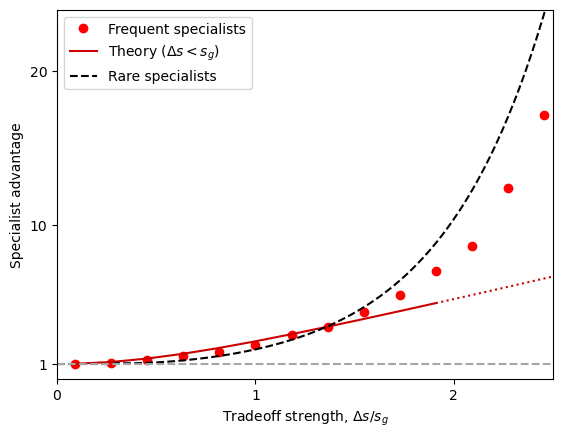

In [ ]:
# FIGURE S7A, rare/frequent comparison in deterministic environments

N = 1e20
ug = 1e-10
us = 1e-10
sg = 0.022
period = 600
s_tradeoff_vals = np.array([0.002, 0.006, 0.01, 0.014,  0.018, 0.022,  0.026,  0.03,  0.034,  0.038,  0.042, 0.046, 0.05, 0.054, 0.058, 0.062, 0.066])

pfix_ratios = np.zeros_like(s_tradeoff_vals)
vpar_est = np.zeros_like(s_tradeoff_vals)
vperp_est = np.zeros_like(s_tradeoff_vals)
analytic_soln = np.zeros_like(s_tradeoff_vals)

for i in range(0,len(s_tradeoff_vals)):

    fname = 'FigS7_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_0_small_output.pickle'

    if os.path.isfile(fname):
        with open(fname,'rb') as file:
            data = pickle.load(file)
    else:
        print(fname)
        continue
    pfix_ratios[i] = data['rate_spec'][0]/data['rate_gen'][0]

    bias_vals = np.array(data['bias_num'])/np.array(data['bias_den'])
    vperp_est[i], _ = s_tradeoff_vals[i] * np.polyfit(range(len(bias_vals) // 2), bias_vals[:len(bias_vals) // 2], 1)
    vpar_est[i] = sg * (data['rate_spec'][0] + data['rate_gen'][0])

tau = period/2

xc_est = vpar_est/sg * np.log(sg/ug) + sg/2

for i in range(0,len(s_tradeoff_vals)):
    analytic_soln[i] = pfix_ratio_frequent_deterministic_small(sg, s_tradeoff_vals[i], tau, xc_est[i], vpar_est[i], vperp_est[i])

plt.plot(s_tradeoff_vals[pfix_ratios>0]/sg, pfix_ratios[pfix_ratios>0],marker='o',linestyle='None',color='red', label = 'Frequent specialists')

plt.plot(s_tradeoff_vals[:11]/sg, analytic_soln[:11],color=[0.8,0,0],label= r'Theory ($\Delta s < s_g$)')
plt.plot(s_tradeoff_vals[10:]/sg, analytic_soln[10:],color=[0.8,0,0],linestyle=':')

ug0 = 2*ug
v0 = sg / (np.log(sg/ug0) ** 2/(2*sg*np.log(N*sg)))
xc0 = sg*2*np.log(N*sg)/np.log(sg/ug0)

plt.plot(np.linspace(0,3*sg,100)/sg, pfix_spec_rare_deterministic(sg, np.linspace(0.001,3*sg,100), tau, xc0, v0)/pfix_gen_rare(sg, xc0, v0), color='black', linestyle='--', label = 'Rare specialists')

plt.xlabel(r'Tradeoff strength, $\Delta s/s_g$')
plt.xticks([0,1,2])
plt.ylabel('Specialist advantage')
plt.yticks([1,10,20])
plt.ylim([0,24])

plt.plot([0,2.5],[1,1],color=[0.65, 0.65, 0.65],linestyle='--')
plt.xlim([0,2.5])
plt.legend()

#plt.savefig(r'Figures\SI_Frequent_Rare_Comparison_Deterministic.pdf', format='pdf')
plt.show()

In [ ]:
# FIGURE S7B, rare/frequent comparison in stochastic environments

sg = 0.02
ug = 3e-9
us = 3e-9
N = 1e20
period = 50
period_CV = 0.4
s_tradeoff_vals = np.array([0.004, 0.008, 0.012, 0.016, 0.02, 0.024, 0.028, 0.032, 0.036, 0.04])

vperp_est = np.zeros(len(s_tradeoff_vals))
vpar_est = np.zeros(len(s_tradeoff_vals))
pfix_spec = np.zeros(len(s_tradeoff_vals))
pfix_gen = np.zeros(len(s_tradeoff_vals))

for i in range(0,len(s_tradeoff_vals)):
    fname = 'FigS7_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV) + '.pickle'
    if os.path.isfile(fname):
        with open(fname,'rb') as file:
            data = pickle.load(file)
    else:
        print(fname)
        continue

    times = np.array(data['times'])
    mut_freqs1 = np.array(data['mut_freqs1'])
    mut_freqs2 = np.array(data['mut_freqs2'])
    mut_freqs3 = np.array(data['mut_freqs3'])

    p_spec = np.polyfit(times[100:], mut_freqs2[100:] + mut_freqs3[100:], 1)[0] / (N * us)
    p_gen = np.polyfit(times[100:], mut_freqs1[100:], 1)[0] / (N * ug)

    vpar_est[i] = (p_spec*us + p_gen*ug)*sg*N
    pfix_spec[i] = p_spec
    pfix_gen[i] = p_gen

    epoch_times = np.array(data['epoch_lengths'])
    epoch_biases = np.array(data['bias_epoch_starts'])
    epoch_times[::2] *= -1

    slope, _ = np.polyfit(epoch_times[:-1], epoch_biases[1:]-epoch_biases[:-1], 1)
    vperp_est[i] = slope * s_tradeoff_vals[i]

xc_est = vpar_est/sg*np.log(sg/ug)+sg/2
tau = period/2


In [ ]:
sigma_vals = np.zeros((len(s_tradeoff_vals), 30))
all_xperp_vals = np.zeros((len(s_tradeoff_vals), 30))

for i in range(len(s_tradeoff_vals)):
    fname = "Xi_Star_Sampling/sample_short_epochs_stoch_params_S7B_" + str(i) + ".pickle"
    with open(fname, 'rb') as f:
        data = pickle.load(f)

    sigma = fit_sigma_eff(sg, s_tradeoff_vals[i], tau, xc_est[i], vpar_est[i], vperp_est[i],
                          period_CV*tau*np.sqrt(2), data['x_vals_all'], data['surv_vals_all'], data['y0_vals'])

    sigma_vals[i,:] = sigma
    all_xperp_vals[i,:] = data['y0_vals']


In [51]:
pfix_spec_est = np.zeros(len(s_tradeoff_vals))
pfix_gen_est  = np.zeros(len(s_tradeoff_vals))

for i in range(len(s_tradeoff_vals)):
    pfix_spec_est[i] = np.exp(pfix_frequent_stochastic_integral(
        sg, s_tradeoff_vals[i], tau, xc_est[i], vpar_est[i], vperp_est[i],
        period_CV*tau*np.sqrt(2), 1.0, all_xperp_vals[i,:], sigma_vals[i,:]))
    pfix_gen_est[i] = np.exp(pfix_frequent_stochastic_integral(
        sg, s_tradeoff_vals[i], tau, xc_est[i], vpar_est[i], vperp_est[i],
        period_CV*tau*np.sqrt(2), 0.0, all_xperp_vals[i,:], sigma_vals[i,:]))

ug0 = 2*ug
v0 = sg / (np.log(sg/ug0) ** 2/(2*sg*np.log(N*sg)))
xc0 = sg*2*np.log(N*sg)/np.log(sg/ug0)
ratio_rare = np.zeros_like(pfix_gen_est)

for i in range(len(s_tradeoff_vals)):
    gen = pfix_spec_rare_stochastic(sg, np.array([s_tradeoff_vals[i]]), tau, xc0, v0, 0.001*period_CV*tau*np.sqrt(2), calc_type=1)
    ratio_rare[i] = pfix_spec_rare_stochastic(sg, np.array([s_tradeoff_vals[i]]), tau, xc0, v0, period_CV*tau*np.sqrt(2), calc_type=1)/gen


C:\Users\johnd\AppData\Local\Temp\ipykernel_19688\2849161411.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ratio_rare[i] = pfix_spec_rare_stochastic(sg, np.array([s_tradeoff_vals[i]]), tau, xc0, v0, period_CV*tau*np.sqrt(2), calc_type=1)/gen


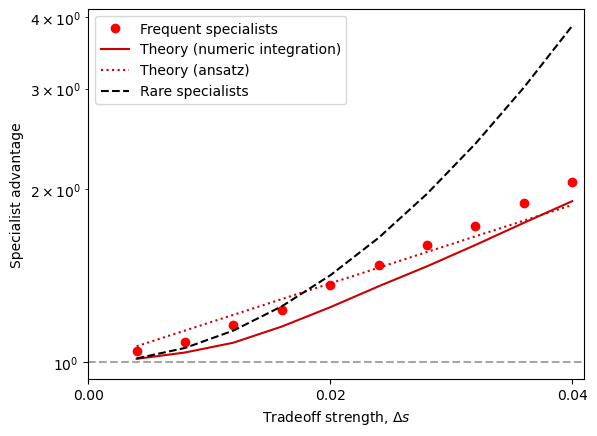

In [52]:
ratio_simple = np.zeros_like(s_tradeoff_vals)
for i in range(len(s_tradeoff_vals)):
    ratio_simple[i] = pfix_ratio_frequent_stochastic_simple(sg, s_tradeoff_vals[i], tau, xc_est[i], vpar_est[i], period_CV*tau*np.sqrt(2))

plt.plot(s_tradeoff_vals, pfix_spec/pfix_gen, marker='o', linestyle='None',color='red', label = 'Frequent specialists')
plt.plot(s_tradeoff_vals, pfix_spec_est/pfix_gen_est,color=[0.8,0,0], label = 'Theory (numeric integration)')
plt.plot(s_tradeoff_vals, ratio_simple,linestyle=':',color=[0.8,0,0], label = 'Theory (ansatz)')

plt.plot(s_tradeoff_vals, ratio_rare,linestyle='--',color='black', label = 'Rare specialists')

plt.plot([0,0.045],[1,1],color=[0.65, 0.65, 0.65],linestyle='--')
plt.xlim([0,0.041])
plt.xticks([0,0.02,0.04])
plt.yticks([1,2,4])
plt.xlabel(r'Tradeoff strength, $\Delta s$')
plt.ylabel('Specialist advantage')
plt.yscale('log')
plt.legend()

#plt.savefig(r'Figures\SI_Frequent_Rare_Comparison_Stochastic.pdf', format='pdf')
plt.show()

In [ ]:
# FIGURE S8A, distribution of effective fitness shift xi* in a stochastic environment

sg = 0.02
ug = 3e-9
us = 3e-9
N = 1e20
period = 50
s_tradeoff_vals2 = np.array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2])
period_CV_vals2 = [0, 0.4, 0.8]
vperp_est2 = np.zeros((len(s_tradeoff_vals2), len(period_CV_vals2)))

vpar_est2 = np.zeros((20,len(period_CV_vals2)))

for i in range(0,len(s_tradeoff_vals2)):
    bias = None
    running_ct = 0

    for j in range(0,len(period_CV_vals2)):
        if j > 0:
            fname = 'Fig4C-5_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals2[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV_vals2[j]) + '.pickle'
        else:
            fname = 'Fig4C-5_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals2[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV_vals2[j]) + '_with_extra_info.pickle'
        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        times = np.array(data['times'])
        mut_freqs1 = np.array(data['mut_freqs1'])
        mut_freqs2 = np.array(data['mut_freqs2'])
        mut_freqs3 = np.array(data['mut_freqs3'])

        pfix_spec = np.polyfit(times[100:], mut_freqs2[100:] + mut_freqs3[100:], 1)[0] / (N * us)
        pfix_gen = np.polyfit(times[100:], mut_freqs1[100:], 1)[0] / (N * ug)

        vpar_est2[i,j] = (pfix_spec*us + pfix_gen*ug)*sg*N
            

        if j == 0:
            if bias is None:
                bias = np.array(data['bias_num'])/(np.array(data['bias_den']))
                running_ct += 1
            else:
                bias += np.array(data['bias_num'])/(np.array(data['bias_den']))
                running_ct += 1
        else:
            epoch_times = np.array(data['epoch_lengths'])
            epoch_biases = np.array(data['bias_epoch_starts'])
            epoch_times[::2] *= -1

            slope, _ = np.polyfit(epoch_times[:-1], epoch_biases[1:]-epoch_biases[:-1], 1)
            vperp_est2[i,j] = slope * s_tradeoff_vals2[i]

        if i == 9 and j == 1:
            epoch_times_to_plot = epoch_times[:-1]
            epoch_bias_diffs_to_plot = epoch_biases[1:]-epoch_biases[:-1]
            

    bias /= running_ct
    bias = np.append(bias, bias[0])

    vperp_est2[i,0] = s_tradeoff_vals2[i]*np.polyfit(range(len(bias) // 2), bias[:len(bias) // 2], 1)[0]
    xc_est2 = vpar_est2/sg*np.log(sg/ug)+sg/2

period = period/2

In [ ]:
tau = period/2

sigma0_vals = np.zeros((len(s_tradeoff_vals2), len(period_CV_vals2)-1))
alpha_vals = np.zeros((len(s_tradeoff_vals2), len(period_CV_vals2)-1))

sigma_eff_vals_all = np.zeros((len(s_tradeoff_vals2), len(period_CV_vals2)-1,30))

for i in range(len(s_tradeoff_vals2)):
    for j in range(len(period_CV_vals2)-1):
        fname = "Xi_Star_Sampling/sample_short_epochs_stoch_params_S8_short_" + str(i) + "_" + str(j) + ".pickle"
        with open(fname, 'rb') as f:
            data = pickle.load(f)
        sigma_eff_vals_all[i,j,:] = fit_sigma_eff(sg, s_tradeoff_vals2[i], tau, xc_est2[i,j+1], vpar_est2[i,j+1], vperp_est2[i,j+1], period_CV_vals2[j+1]*tau*np.sqrt(2), data['x_vals_all'], data['surv_vals_all'], data['y0_vals'])  

        # Quadratic fit to sigma_eff
        n = max(4, np.searchsorted(data['y0_vals'], 2*s_tradeoff_vals2[i]) + 1)
        n = min(n, len(data['y0_vals']))
        sigma0_vals[i,j], alpha_vals[i,j] = fit_sigma_quadratic(data['y0_vals'], sigma_eff_vals_all[i,j,:], n)

        if i == 9 and j == 0:
            x_vals_to_plot = [data['x_vals_all'][0], data['x_vals_all'][15]]
            surv_vals_to_plot = [data['surv_vals_all'][0], data['surv_vals_all'][15]]
            xperp_to_plot = data['y0_vals']

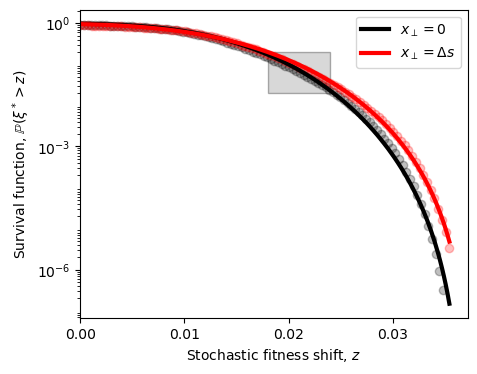

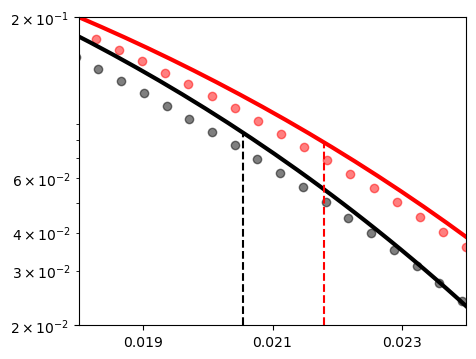

In [55]:
plt.figure(figsize=(5,4))

plt.plot(x_vals_to_plot[0], surv_vals_to_plot[0], marker='o', color='black',linestyle='None',alpha=0.25)
plt.plot(x_vals_to_plot[1], surv_vals_to_plot[1], marker='o', color='red',linestyle='None',alpha=0.25)

x_vals = np.linspace(0, np.max(x_vals_to_plot), 200)
mu_plot = analytic_mu(sg, s_tradeoff_vals2[9], tau, xc_est2[9,1], vpar_est2[9,1], vperp_est2[9,1], period_CV_vals2[1]*tau*np.sqrt(2))
cutoff_plot1 = analytic_cutoff(sg, s_tradeoff_vals2[9], xc_est2[9,1], vpar_est2[9,1], vperp_est2[9,1], xperp_to_plot[0])
cutoff_plot2 = analytic_cutoff(sg, s_tradeoff_vals2[9], xc_est2[9,1], vpar_est2[9,1], vperp_est2[9,1], xperp_to_plot[15])

plt.plot(x_vals, np.exp(log_survival(x_vals, mu_plot, sigma_eff_vals_all[9,0,0], cutoff_plot1)),color='black',linewidth=3,label=r'$x_\perp = 0$')
plt.plot(x_vals, np.exp(log_survival(x_vals, mu_plot, sigma_eff_vals_all[9,0,15], cutoff_plot2)),color='red',linewidth=3,label=r'$x_\perp = \Delta s$')
plt.legend()

plt.xlabel(r'Stochastic fitness shift, $z$')
plt.ylabel(r'Survival function, $\mathbb{P}(\xi^* > z)$')

plt.yscale('log')
plt.yticks([1e-6,1e-3,1])

plt.xlim(left=0)
plt.xticks([0,0.01,0.02,0.03])

x_patches = (0.018, 0.024)
y_patches = (0.02, 0.2)

ax = plt.gca()
rect = patches.Rectangle(
    (x_patches[0], y_patches[0]),              # (x, y)
    x_patches[1] - x_patches[0],              # width
    y_patches[1] - y_patches[0],               # height
    facecolor='gray',
    edgecolor='black',
    alpha=0.3
)
ax.add_patch(rect)
#plt.savefig(r'Figures\SI_Stochasticity_Tail.pdf', format='pdf')
plt.show()

plt.figure(figsize=(5,4))

plt.plot(x_vals_to_plot[0], surv_vals_to_plot[0], marker='o', color='black',linestyle='None',alpha=0.5)
plt.plot(x_vals_to_plot[1], surv_vals_to_plot[1], marker='o', color='red',linestyle='None',alpha=0.5)
plt.plot(x_vals, np.exp(log_survival(x_vals, mu_plot, sigma_eff_vals_all[9,0,0], cutoff_plot1)),color='black',linewidth=3,label=r'$x_\perp = 0$')
plt.plot(x_vals, np.exp(log_survival(x_vals, mu_plot, sigma_eff_vals_all[9,0,15], cutoff_plot2)),color='red',linewidth=3,label=r'$x_\perp = \Delta s$')

plt.xlim(x_patches)
plt.ylim(y_patches)
plt.yscale('log')

x_line = mu_plot + sigma_eff_vals_all[9,0,0]
y_line = np.exp(log_survival(x_line, mu_plot, sigma_eff_vals_all[9,0,0], cutoff_plot1))
plt.plot([x_line, x_line], [y_patches[0], y_line], color='black', linestyle='--')

x_line = mu_plot + sigma_eff_vals_all[9,0,15]
y_line = np.exp(log_survival(x_line, mu_plot, sigma_eff_vals_all[9,0,15], cutoff_plot2))
plt.plot([x_line, x_line], [y_patches[0], y_line], color='red', linestyle='--')

plt.xticks([0.019, 0.021, 0.023])
plt.yticks([0.02, 0.2])
#plt.savefig(r'Figures\SI_Stochasticity_Tail_Inset.pdf', format='pdf')
plt.show()


Sigma0 coeff: 0.13776855754511258
Alpha coeff: 0.8880561688373307


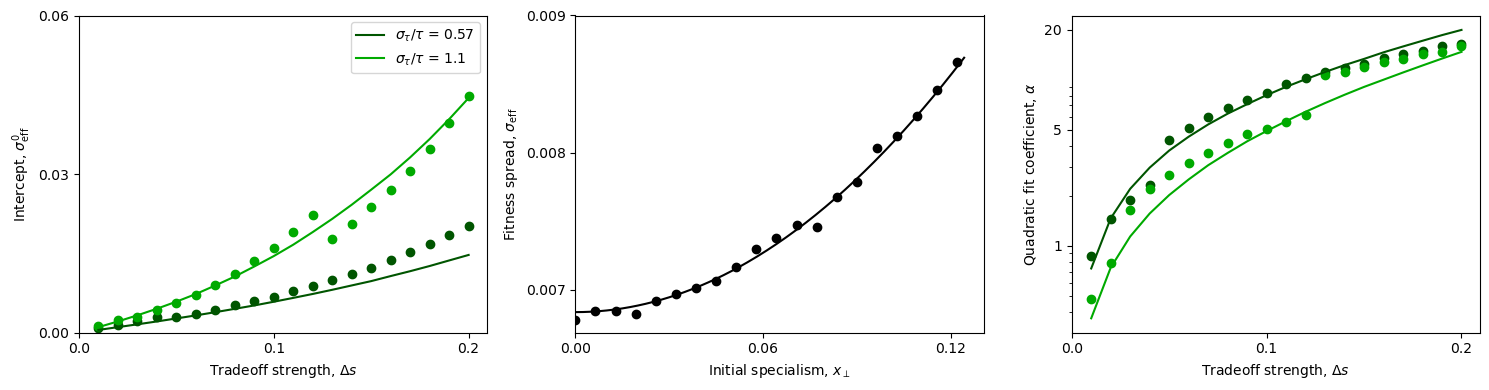

In [56]:
# FIGURE S8B-D, semianalytic approximations to distribution of xi^*

tau = period/2

colors = np.array(range(0,3))/3
colors = [(0, c, 0, 1) for c in colors]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

# ---------------- Plot 1 ----------------
ax = axes[0]

ax.plot(s_tradeoff_vals2, sigma0_vals[:,0],marker='o', linestyle='None', color=colors[1])
ax.plot(s_tradeoff_vals2, sigma0_vals[:,1],marker='o', linestyle='None', color=colors[2])

A = np.array([sigma0_ansatz(sg, s_tradeoff_vals2, tau, xc_est2[:,j+1], vpar_est2[:,j+1], period_CV_vals2[j+1]*tau*np.sqrt(2)) for j in range(2)]).T
COEFF_SIGMA_0 = np.sum(A * sigma0_vals) / np.sum(A**2)
print("Sigma0 coeff:", COEFF_SIGMA_0)

sigma0_pred1 = COEFF_SIGMA_0 * sigma0_ansatz(sg, s_tradeoff_vals2, tau, xc_est2[:,1], vpar_est2[:,1], period_CV_vals2[1]*tau*np.sqrt(2))
sigma0_pred2 = COEFF_SIGMA_0 * sigma0_ansatz(sg, s_tradeoff_vals2, tau, xc_est2[:,2], vpar_est2[:,2], period_CV_vals2[2]*tau*np.sqrt(2))

ax.plot(s_tradeoff_vals2, sigma0_pred1, color=colors[1], label=rf'$\sigma_\tau/\tau$ = {np.sqrt(2)*period_CV_vals2[1]:.2g}')
ax.plot(s_tradeoff_vals2, sigma0_pred2, color=colors[2], label=rf'$\sigma_\tau/\tau$ = {np.sqrt(2)*period_CV_vals2[2]:.2g}')

ax.set_xlabel(r'Tradeoff strength, $\Delta s$')
ax.set_ylabel(r'Intercept, $\sigma_\mathrm{eff}^0$')
ax.set_ylim(bottom=0)
ax.set_yticks([0,0.03,0.06])
ax.set_xlim(left=0)
ax.set_xticks([0,0.1,0.2])
ax.legend()

# ---------------- Plot 2 ----------------
ax = axes[1]

ax.plot(xperp_to_plot[:2*len(xperp_to_plot)//3], sigma_eff_vals_all[9,0,:2*len(xperp_to_plot)//3],
        color='black', marker='o', linestyle='None')

x_fit = np.linspace(np.min(xperp_to_plot), np.max(xperp_to_plot)*2/3, 200)
ax.plot(x_fit, sigma0_vals[9,0] + x_fit**2/alpha_vals[9,0],color='black')

ax.set_xlabel(r'Initial specialism, $x_\perp$')
ax.set_ylabel(r'Fitness spread, $\sigma_\mathrm{eff}$')
ax.set_xlim(left=0)
ax.set_xticks([0,0.06,0.12])
ax.set_yticks([0.007, 0.008, 0.009])

# ---------------- Plot 3 ----------------
ax = axes[2]

ax.plot(s_tradeoff_vals2, alpha_vals[:,0],marker='o', linestyle='None', color=colors[1])
ax.plot(s_tradeoff_vals2, alpha_vals[:,1],marker='o', linestyle='None', color=colors[2])

A = np.array([alpha_ansatz(sg, s_tradeoff_vals2, tau, xc_est2[:,j+1], vpar_est2[:,j+1], period_CV_vals2[j+1]*tau*np.sqrt(2)) for j in range(2)]).T
COEFF_ALPHA = np.sum(A * alpha_vals) / np.sum(A**2)
print("Alpha coeff:", COEFF_ALPHA)

alpha_pred1 = COEFF_ALPHA * alpha_ansatz(sg, s_tradeoff_vals2, tau, xc_est2[:,1], vpar_est2[:,1], period_CV_vals2[1]*tau*np.sqrt(2))
alpha_pred2 = COEFF_ALPHA * alpha_ansatz(sg, s_tradeoff_vals2, tau, xc_est2[:,2], vpar_est2[:,2], period_CV_vals2[2]*tau*np.sqrt(2))

ax.plot(s_tradeoff_vals2, alpha_pred1, color=colors[1])
ax.plot(s_tradeoff_vals2, alpha_pred2, color=colors[2])

ax.set_xlim(left=0)
ax.set_xlabel(r'Tradeoff strength, $\Delta s$')
ax.set_ylabel(r'Quadratic fit coefficient, $\alpha$')
ax.set_yscale('log')
ax.set_yticks([1,5,20])
ax.set_yticklabels(['1', '5', '20'])
ax.set_xticks([0,0.1,0.2])

# ---------------- Final layout ----------------
plt.tight_layout()

#plt.savefig(r'Figures\SI_Stochasticity_Short.pdf', format='pdf')
plt.show()

In [57]:
sg = 0.02
ug = 3e-9
us = 3e-9
N = 1e20
period = 250
s_tradeoff_vals1 = np.array([0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095, 0.1])
period_CV_vals1 = [0, 0.4, 0.8]
vperp_est1 = np.zeros((len(s_tradeoff_vals1), len(period_CV_vals1)))

vpar_est1 = np.zeros((len(s_tradeoff_vals1),len(period_CV_vals1)))

for i in range(0,len(s_tradeoff_vals1)):
    bias = None
    running_ct = 0

    for j in range(0,len(period_CV_vals1)):
        if j > 0:
            fname = 'Fig4C-5_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals1[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV_vals1[j]) + '.pickle'
        else:
            fname = 'Fig4C-5_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals1[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV_vals1[j]) + '_with_extra_info.pickle'
        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        times = np.array(data['times'])
        mut_freqs1 = np.array(data['mut_freqs1'])
        mut_freqs2 = np.array(data['mut_freqs2'])
        mut_freqs3 = np.array(data['mut_freqs3'])

        pfix_spec = np.polyfit(times[100:], mut_freqs2[100:] + mut_freqs3[100:], 1)[0] / (N * us)
        pfix_gen = np.polyfit(times[100:], mut_freqs1[100:], 1)[0] / (N * ug)

        vpar_est1[i,j] = (pfix_spec*us + pfix_gen*ug)*sg*N
            

        if j == 0:
            if bias is None:
                bias = np.array(data['bias_num'])/(np.array(data['bias_den']))
                running_ct += 1
            else:
                bias += np.array(data['bias_num'])/(np.array(data['bias_den']))
                running_ct += 1
        else:
            epoch_times = np.array(data['epoch_lengths'])
            epoch_biases = np.array(data['bias_epoch_starts'])
            epoch_times[::2] *= -1

            slope, _ = np.polyfit(epoch_times[:-1], epoch_biases[1:]-epoch_biases[:-1], 1)
            vperp_est1[i,j] = slope * s_tradeoff_vals1[i]

    bias /= running_ct
    bias = np.append(bias, bias[0])

    vperp_est1[i,0] = s_tradeoff_vals1[i]*np.polyfit(range(len(bias) // 2), bias[:len(bias) // 2], 1)[0]
    xc_est1 = vpar_est1/sg*np.log(sg/ug)+sg/2

tau = period/2


In [ ]:
tau = period/2

sigma0_vals = np.zeros((len(s_tradeoff_vals1), len(period_CV_vals1)-1))
alpha_vals = np.zeros((len(s_tradeoff_vals1), len(period_CV_vals1)-1))

sigma_eff_vals_all = np.zeros((len(s_tradeoff_vals1), len(period_CV_vals1)-1, 30))

for i in range(len(s_tradeoff_vals1)):
    for j in range(len(period_CV_vals1)-1):
        fname = "Xi_Star_Sampling/sample_long_epochs_stoch_params_S8_long_" + str(i) + "_" + str(j) + ".pickle"
        with open(fname, 'rb') as f:
            data = pickle.load(f)

        sigma_tau = period_CV_vals1[j+1]*tau*np.sqrt(2)

        sigma_eff_vals_all[i,j,:] = fit_sigma_eff(sg, s_tradeoff_vals1[i], tau, xc_est1[i,j+1], vpar_est1[i,j+1], vperp_est1[i,j+1], sigma_tau, data['x_vals_all'], data['surv_vals_all'], data['y0_vals'])

        # Quadratic fit to sigma_eff
        n = max(4, np.searchsorted(data['y0_vals'], 2*s_tradeoff_vals1[i]) + 1)
        n = min(n, len(data['y0_vals']))
        sigma0_vals[i,j], alpha_vals[i,j] = fit_sigma_quadratic(data['y0_vals'], sigma_eff_vals_all[i,j,:], n)

Sigma0 coeff: 0.08638556225797628
Alpha coeff: 3.5802631595992405


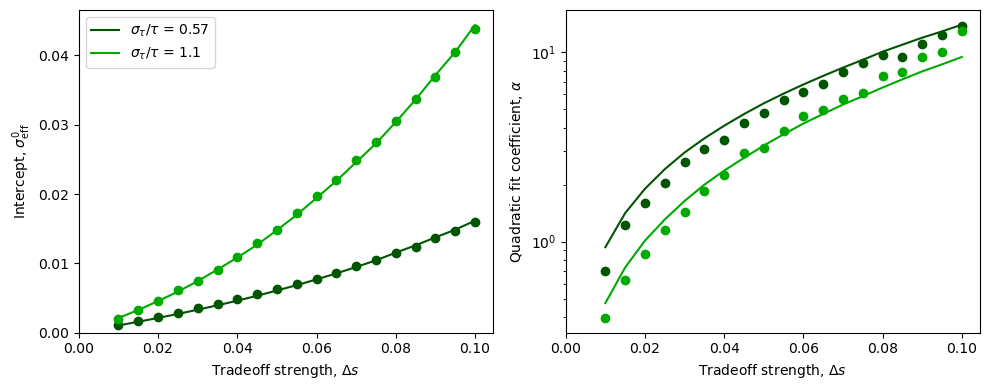

In [59]:
tau = period/2

colors = np.array(range(0,3))/3
colors = [(0, c, 0, 1) for c in colors]

fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=False)

# ---------------- Plot 1 ----------------
ax = axes[0]

ax.plot(s_tradeoff_vals1, sigma0_vals[:,0],marker='o', linestyle='None', color=colors[1])
ax.plot(s_tradeoff_vals1, sigma0_vals[:,1],marker='o', linestyle='None', color=colors[2])

A = np.array([sigma0_ansatz(sg, s_tradeoff_vals1, tau, xc_est1[:,j+1], vpar_est1[:,j+1], period_CV_vals1[j+1]*tau*np.sqrt(2)) for j in range(sigma0_vals.shape[1])]).T
COEFF_SIGMA_0 = np.sum(A * sigma0_vals) / np.sum(A**2)
print("Sigma0 coeff:", COEFF_SIGMA_0)

sigma0_pred1 = COEFF_SIGMA_0 * sigma0_ansatz(sg, s_tradeoff_vals1, tau, xc_est1[:,1], vpar_est1[:,1], period_CV_vals1[1]*tau*np.sqrt(2))
sigma0_pred2 = COEFF_SIGMA_0 * sigma0_ansatz(sg, s_tradeoff_vals1, tau, xc_est1[:,2], vpar_est1[:,2], period_CV_vals1[2]*tau*np.sqrt(2))

ax.plot(s_tradeoff_vals1, sigma0_pred1, color=colors[1], label=rf'$\sigma_\tau/\tau$ = {np.sqrt(2)*period_CV_vals1[1]:.2g}')
ax.plot(s_tradeoff_vals1, sigma0_pred2, color=colors[2], label=rf'$\sigma_\tau/\tau$ = {np.sqrt(2)*period_CV_vals1[2]:.2g}')

ax.set_xlabel(r'Tradeoff strength, $\Delta s$')
ax.set_ylabel(r'Intercept, $\sigma_\mathrm{eff}^0$')
ax.set_ylim(bottom=0)
ax.set_xlim(left=0)
ax.legend()

# ---------------- Plot 2 ----------------
ax = axes[1]

ax.plot(s_tradeoff_vals1, alpha_vals[:,0],marker='o', linestyle='None', color=colors[1])
ax.plot(s_tradeoff_vals1, alpha_vals[:,1],marker='o', linestyle='None', color=colors[2])

A = np.array([alpha_ansatz(sg, s_tradeoff_vals1, tau, xc_est1[:,j+1], vpar_est1[:,j+1], period_CV_vals1[j+1]*tau*np.sqrt(2)) for j in range(alpha_vals.shape[1])]).T
COEFF_ALPHA = np.sum(A * alpha_vals) / np.sum(A**2)
print("Alpha coeff:", COEFF_ALPHA)

alpha_pred1 = COEFF_ALPHA * alpha_ansatz(sg, s_tradeoff_vals1, tau, xc_est1[:,1], vpar_est1[:,1], period_CV_vals1[1]*tau*np.sqrt(2))
alpha_pred2 = COEFF_ALPHA * alpha_ansatz(sg, s_tradeoff_vals1, tau, xc_est1[:,2], vpar_est1[:,2], period_CV_vals1[2]*tau*np.sqrt(2))

ax.plot(s_tradeoff_vals1, alpha_pred1, color=colors[1])
ax.plot(s_tradeoff_vals1, alpha_pred2, color=colors[2])

ax.set_xlim(left=0)
ax.set_xlabel(r'Tradeoff strength, $\Delta s$')
ax.set_ylabel(r'Quadratic fit coefficient, $\alpha$')
ax.set_yscale('log')

# ---------------- Final layout ----------------
plt.tight_layout()

#plt.savefig(r'Figures\SI_Stochasticity_Long.pdf', format='pdf')
plt.show()

In [ ]:
# FIGURE S9: Rate of adaptation depends on the JDFE

s_tradeoff_vals = np.array([0.03, 0.06, 0.09])
ds0_vals = np.array([0, -0.002, -0.004, -0.006, -0.008, -0.01, -0.012, -0.014, -0.016, -0.018, -0.02, -0.022, -0.024, -0.026, -0.028, -0.03])


vpar_est = np.zeros((len(s_tradeoff_vals), len(ds0_vals)))
pfix_ratios = np.zeros((len(s_tradeoff_vals), len(ds0_vals)))

ug = 3e-9
us = 3e-9
N = 1e20
period = 250
sg = 0.02
period_CV = 0.8

fname = 'FigS9_Data/N_' + str(N) + '_us_0_ss_0_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_400_dtau_1.0_small_output.pickle'
with open(fname,'rb') as file:
    data = pickle.load(file)
v0 = sg * data['rate_gen'][0]

for i in range(len(s_tradeoff_vals)):
    for j in range(0,len(ds0_vals)):
        if j == 0:
            fname = 'FigS9_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV) + '_small_output.pickle'
        else:
            fname = 'FigS9_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV) + '_small_output_ds0_' + str(ds0_vals[j]) + '_all.pickle'
        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        vpar_est[i,j] = sg * data['rate_gen'][0] + (sg + ds0_vals[j]) * data['rate_spec'][0]
        pfix_ratios[i,j] = data['rate_spec'][0]/data['rate_gen'][0]


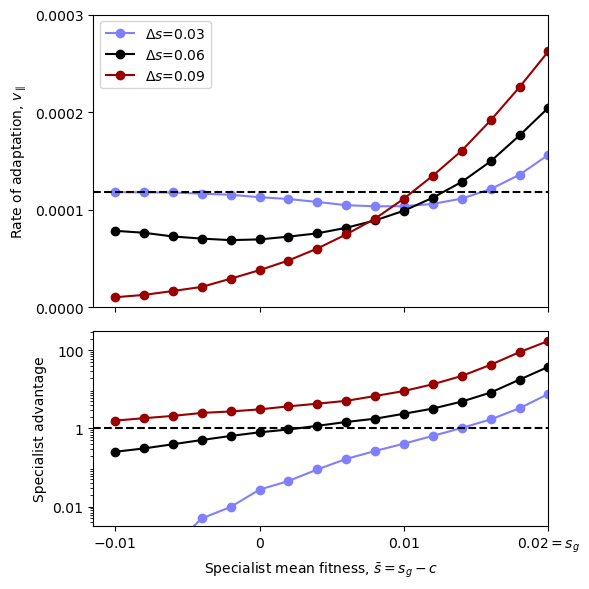

In [61]:
fig, axes = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(6, 6),
    gridspec_kw={'height_ratios': [1.5, 1]}
)

colors = [[0.5, 0.5, 1], 'black', [0.6, 0, 0]]
labels = [rf'$\Delta s$={s_tradeoff}' for s_tradeoff in s_tradeoff_vals]

# Rate of adaptation
for row, color, label in zip(vpar_est, colors, labels):
    axes[0].plot(ds0_vals + sg, row, marker='o', color=color, label=label)

axes[0].axhline(y=v0, color='black', linestyle='--')
axes[0].set_ylabel(r'Rate of adaptation, $v_\parallel$')
axes[0].set_ylim([0, np.max(vpar_est) * 1.05])
axes[0].set_yticks([0, 0.0001, 0.0002, 0.0003])
axes[0].legend()

# Fixation probability ratios
for row, color, label in zip(pfix_ratios, colors, labels):
    axes[1].plot(ds0_vals + sg, row, marker='o', color=color, label=label)

axes[1].set_xlabel(r'Specialist mean fitness, $\bar{s} = s_g - c$')
axes[1].set_ylabel('Specialist advantage')
axes[1].set_yscale('log')
axes[1].set_xticks([-0.01, 0, 0.01, 0.02], labels = [r'$-0.01$', r'$0$', r'$0.01$', r'$0.02 = s_g$'])
axes[1].set_ylim([10**(-2.5), 10**(2.5)])
axes[1].set_yticks([0.01, 1, 100], labels=['0.01', '1', '100'])
axes[1].axhline(y=1, color='black', linestyle='--')
axes[1].set_xlim(right = 0.02)


plt.tight_layout()

#plt.savefig(r'Figures\SI_Adaptation_DFE.pdf', format='pdf')

plt.show()


In [62]:
# FIGURE S10: Rate of specialization in stochastic environments

sg = 0.02
ug = 3e-9
us = 3e-9
N = 1e20
period = 250
s_tradeoff_vals1 = np.array([0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095, 0.1])
period_CV_vals1 = [0, 0.4, 0.8]
vperp_est1 = np.zeros((len(s_tradeoff_vals1), len(period_CV_vals1)))

vpar_est1 = np.zeros((len(s_tradeoff_vals1),len(period_CV_vals1)))

for i in range(0,len(s_tradeoff_vals1)):
    bias = None
    running_ct = 0

    for j in range(0,len(period_CV_vals1)):
        if j > 0:
            fname = 'Fig4C-5_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals1[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV_vals1[j]) + '.pickle'
        else:
            fname = 'Fig4C-5_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals1[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV_vals1[j]) + '_with_extra_info.pickle'
        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        times = np.array(data['times'])
        mut_freqs1 = np.array(data['mut_freqs1'])
        mut_freqs2 = np.array(data['mut_freqs2'])
        mut_freqs3 = np.array(data['mut_freqs3'])

        pfix_spec = np.polyfit(times[100:], mut_freqs2[100:] + mut_freqs3[100:], 1)[0] / (N * us)
        pfix_gen = np.polyfit(times[100:], mut_freqs1[100:], 1)[0] / (N * ug)

        vpar_est1[i,j] = (pfix_spec*us + pfix_gen*ug)*sg*N

        if j == 0:
            if bias is None:
                bias = np.array(data['bias_num'])/(np.array(data['bias_den']))
                running_ct += 1
            else:
                bias += np.array(data['bias_num'])/(np.array(data['bias_den']))
                running_ct += 1
        else:
            epoch_times = np.array(data['epoch_lengths'])
            epoch_biases = np.array(data['bias_epoch_starts'])
            epoch_times[::2] *= -1

            slope, _ = np.polyfit(epoch_times[:-1], epoch_biases[1:]-epoch_biases[:-1], 1)
            vperp_est1[i,j] = slope * s_tradeoff_vals1[i]

    bias /= running_ct
    bias = np.append(bias, bias[0])

    vperp_est1[i,0] = s_tradeoff_vals1[i]*np.polyfit(range(len(bias) // 2), bias[:len(bias) // 2], 1)[0]

period = 125


In [63]:
sg = 0.02
ug = 3e-9
us = 3e-9
N = 1e20
period = 50
s_tradeoff_vals2 = np.array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2])
period_CV_vals2 = [0, 0.4, 0.8]
vperp_est2 = np.zeros((len(s_tradeoff_vals2), len(period_CV_vals2)))

vpar_est2 = np.zeros((len(s_tradeoff_vals2),len(period_CV_vals2)))

for i in range(0,len(s_tradeoff_vals2)):
    bias = None
    running_ct = 0

    for j in range(0,len(period_CV_vals2)):
        if j > 0:
            fname = 'Fig4C-5_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals2[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV_vals2[j]) + '.pickle'
        else:
            fname = 'Fig4C-5_Data/N_' + str(N) + '_us_' + str(us) + '_ss_' + str(s_tradeoff_vals2[i]) + '_ug_' + str(ug) + '_sg_' + str(sg) + '_tau_' + str(period) + '_dtau_' + str(period_CV_vals2[j]) + '_with_extra_info.pickle'
        if os.path.isfile(fname):
            with open(fname,'rb') as file:
                data = pickle.load(file)
        else:
            print(fname)
            continue

        times = np.array(data['times'])
        mut_freqs1 = np.array(data['mut_freqs1'])
        mut_freqs2 = np.array(data['mut_freqs2'])
        mut_freqs3 = np.array(data['mut_freqs3'])

        pfix_spec = np.polyfit(times[100:], mut_freqs2[100:] + mut_freqs3[100:], 1)[0] / (N * us)
        pfix_gen = np.polyfit(times[100:], mut_freqs1[100:], 1)[0] / (N * ug)

        vpar_est2[i,j] = (pfix_spec*us + pfix_gen*ug)*sg*N

        if j == 0:
            if bias is None:
                bias = np.array(data['bias_num'])/(np.array(data['bias_den']))
                running_ct += 1
            else:
                bias += np.array(data['bias_num'])/(np.array(data['bias_den']))
                running_ct += 1
        else:
            epoch_times = np.array(data['epoch_lengths'])
            epoch_biases = np.array(data['bias_epoch_starts'])
            epoch_times[::2] *= -1

            slope, _ = np.polyfit(epoch_times[:-1], epoch_biases[1:]-epoch_biases[:-1], 1)
            vperp_est2[i,j] = slope * s_tradeoff_vals2[i]

        if i == 9 and j == 1:
            epoch_times_to_plot = epoch_times[:-1]
            epoch_bias_diffs_to_plot = epoch_biases[1:]-epoch_biases[:-1]

    bias /= running_ct
    bias = np.append(bias, bias[0])

    vperp_est2[i,0] = s_tradeoff_vals2[i]*np.polyfit(range(len(bias) // 2), bias[:len(bias) // 2], 1)[0]

period = period/2

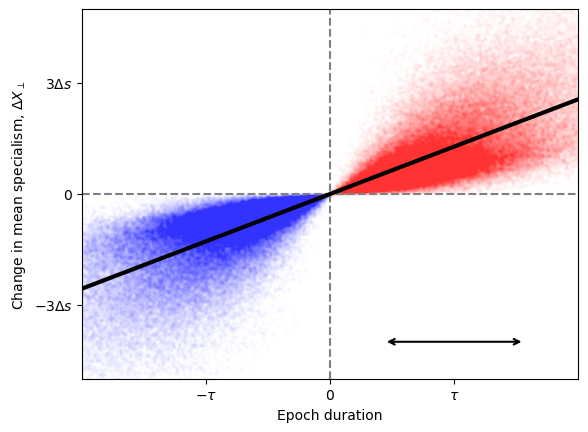

In [64]:
plt.plot(epoch_times_to_plot[epoch_times_to_plot > 0], epoch_bias_diffs_to_plot[epoch_times_to_plot > 0],linestyle='None',marker='o',markersize=2,alpha=0.01,color=[1,0.2,0.2])
plt.plot(epoch_times_to_plot[epoch_times_to_plot < 0], epoch_bias_diffs_to_plot[epoch_times_to_plot < 0],linestyle='None',marker='o',markersize=2,alpha=0.01,color=[0.2,0.2,1])

plt.xlim([-50,50])
plt.ylim([-5,5])
plt.xlabel('Epoch duration')
plt.ylabel(r'Change in mean specialism, $\Delta X_\perp$')

tau = 25
sigma_tau = 0.4*tau*np.sqrt(2)
plt.xticks([-tau, 0, tau], labels=[r'$-\tau$', r'$0$', r'$\tau$'])
plt.yticks([-3,0,3],labels = [r'$-3\Delta s$', r'$0$', r'$3\Delta s$'])
plt.plot([0,0],[-5,5], color='gray',linestyle='--')
plt.plot([-50,50],[0,0], color='gray',linestyle='--')

plt.annotate(
    "",
    xy=(tau + sigma_tau, -4),
    xytext=(tau - sigma_tau, -4),
    arrowprops=dict(arrowstyle="<->", color='black', linewidth=1.5),
)

x_vals = np.linspace(-50, 50, 200)
y_vals = x_vals * vperp_est2[9,1] / s_tradeoff_vals2[9]
plt.plot(x_vals, y_vals, color='black',linewidth=3)
#plt.savefig(r'Figures\SI_Stochastic_Specialization_Rate_Fit.png', format='png')
plt.show()



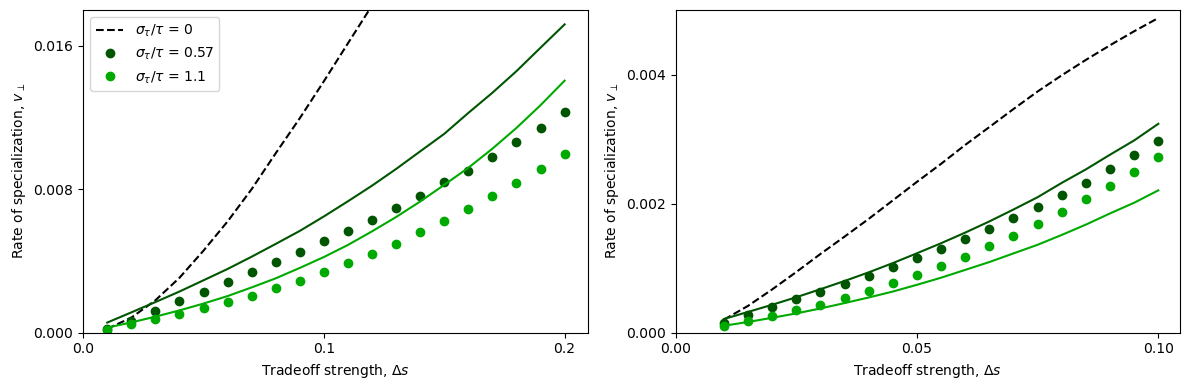

In [65]:
tau = 25
vperp_pred2 = np.zeros((len(s_tradeoff_vals2), len(period_CV_vals2)-1))
for i in range(len(s_tradeoff_vals2)):
    for j in range(len(period_CV_vals2)-1):
        vperp_pred2[i,j] = vperp_est_stochastic(sg, s_tradeoff_vals2[i], tau, vpar_est2[i,j+1], period_CV_vals2[j+1]*tau*np.sqrt(2), ug, long_cycle = False)

tau = 125
vperp_pred1 = np.zeros((len(s_tradeoff_vals1), len(period_CV_vals1)-1))
for i in range(len(s_tradeoff_vals1)):
    for j in range(len(period_CV_vals1)-1):
        vperp_pred1[i,j] = vperp_est_stochastic(sg, s_tradeoff_vals1[i], tau, vpar_est1[i,j+1], period_CV_vals1[j+1]*tau*np.sqrt(2), ug, long_cycle=True)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

colors = np.array(range(0,len(period_CV_vals1)))/len(period_CV_vals1)
colors = [(0, c, 0, 1) for c in colors]

# Left: vperp vs s_tradeoff_vals2
axs[0].plot(s_tradeoff_vals2, vperp_est2[:,0], color=colors[0], linestyle='--', label = rf'$\sigma_\tau/\tau$ = {np.sqrt(2)*period_CV_vals2[0]:.2g}')
axs[0].plot(s_tradeoff_vals2, vperp_est2[:,1], color=colors[1], marker='o', linestyle='None', label = rf'$\sigma_\tau/\tau$ = {np.sqrt(2)*period_CV_vals2[1]:.2g}')
axs[0].plot(s_tradeoff_vals2, vperp_est2[:,2], color=colors[2], marker='o', linestyle='None', label = rf'$\sigma_\tau/\tau$ = {np.sqrt(2)*period_CV_vals2[2]:.2g}')

axs[0].plot(s_tradeoff_vals2, vperp_pred2[:,0], color=colors[1])
axs[0].plot(s_tradeoff_vals2, vperp_pred2[:,1], color=colors[2])


axs[0].set_xlabel(r'Tradeoff strength, $\Delta s$')
axs[0].set_ylabel(r'Rate of specialization, $v_\perp$')
axs[0].set_ylim(bottom=0)
axs[0].set_xticks([0,0.1,0.2])
axs[0].set_yticks([0,0.008, 0.016])
axs[0].set_ylim(top=0.018)
axs[0].legend()

# Right: vperp vs s_tradeoff_vals1
axs[1].plot(s_tradeoff_vals1, vperp_est1[:,0], color=colors[0], linestyle='--')
axs[1].plot(s_tradeoff_vals1, vperp_est1[:,1], color=colors[1], marker='o', linestyle='None')
axs[1].plot(s_tradeoff_vals1, vperp_est1[:,2], color=colors[2], marker='o', linestyle='None')

axs[1].plot(s_tradeoff_vals1, vperp_pred1[:,0], color=colors[1])
axs[1].plot(s_tradeoff_vals1, vperp_pred1[:,1], color=colors[2])

axs[1].set_xlabel(r'Tradeoff strength, $\Delta s$')
axs[1].set_ylabel(r'Rate of specialization, $v_\perp$')
axs[1].set_ylim(bottom=0)
axs[1].set_xticks([0,0.05,0.1])
axs[1].set_yticks([0,0.002,0.004])
axs[1].set_ylim(top=0.005)


plt.tight_layout()
#plt.savefig(r'Figures\SI_Stochastic_Specialization_Rate_Theory.pdf', format='pdf')

plt.show()